In [1]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')    

import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *
from utils_data_vis import *

In [2]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"
HORA_CRITICA_WD = "422369"

hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2
hour_window_wd = 6

limites = True

In [3]:
# CH
# Hashtags como nodos
if limites:
	lim_ch_und = int(210/hour_window_ch)
	lim_ch_sup = int(337/hour_window_ch)
else:
	lim_ch_und = None
	lim_ch_sup = None

# WD
# Hashtags como nodos
if limites:
	lim_wd_und = int(180/hour_window_wd)
	lim_wd_sup = None
else:
	lim_wd_und = None
	lim_wd_sup = None


# Análisis Exploratorio de Datos (EDA) y creación de grafos

In [4]:
df_nat = read_data("nat", datasets_folder=datasets_folder)
df_9n = read_data("9n", datasets_folder=datasets_folder)
df_ch = read_data("ch", datasets_folder=datasets_folder)
df_wd = read_data("wd", datasets_folder=datasets_folder)

## Número de usuarios y hashtags únicos por hora

In [5]:
print("No al Tarifazo: número de usuarios únicos:", df_nat["user"].unique().shape[0], ", hashtags únicos:", df_nat["hashtag"].unique().shape[0], ", horas únicas:", df_nat["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("9n: número de usuarios únicos:", df_9n["user"].unique().shape[0], ", hashtags únicos:", df_9n["hashtag"].unique().shape[0], ", horas únicas::", df_9n["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("Charlie Hebdo: número de usuarios únicos:", df_ch["user"].unique().shape[0], ", hashtags únicos:", df_ch["hashtag"].unique().shape[0], ", horas únicas:", df_ch["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("Womanday: número de usuarios únicos:", df_wd["user"].unique().shape[0], ", hashtags únicos:", df_wd["hashtag"].unique().shape[0], ", horas únicas:", df_wd["hour"].unique().shape[0], "en el conjunto de datos.\n")

No al Tarifazo: número de usuarios únicos: 9670 , hashtags únicos: 23398 , horas únicas: 260 en el conjunto de datos.

9n: número de usuarios únicos: 8022 , hashtags únicos: 18717 , horas únicas:: 97 en el conjunto de datos.

Charlie Hebdo: número de usuarios únicos: 16146 , hashtags únicos: 37598 , horas únicas: 504 en el conjunto de datos.

Womanday: número de usuarios únicos: 2319 , hashtags únicos: 10074 , horas únicas: 283 en el conjunto de datos.



In [6]:
hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]
hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]
hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]
hour_wd = np.sort(df_wd["hour"].unique())[::hour_window_wd]


# Ajusto la ventana a la que pertence la hora critica de WD
"""HORA_CRITICA_9N = str(int(HORA_CRITICA_9N) - (int(HORA_CRITICA_9N)-int(hour_9n[0]))%hour_window_9n)
HORA_CRITICA_NAT = str(int(HORA_CRITICA_NAT) - (int(HORA_CRITICA_NAT)-int(hour_nat[0]))%hour_window_nat)
HORA_CRITICA_CH = str(int(HORA_CRITICA_CH) - (int(HORA_CRITICA_CH)-int(hour_ch[0]))%hour_window_ch)
HORA_CRITICA_WD = str(int(HORA_CRITICA_WD) - (int(HORA_CRITICA_WD)-int(hour_wd[0]))%hour_window_wd)"""

# Convierto la hora a formato año, mes, día, hora
hour_nat_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_nat]
hour_9n_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_9n]
hour_ch_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_ch]
hour_wd_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_wd]

In [7]:
print("La nueva hora crítica 9N es:", HORA_CRITICA_9N)
print("La nueva hora crítica NAT es:", HORA_CRITICA_NAT)
print("La nueva hora crítica CH es:", HORA_CRITICA_CH)
print("La nueva hora crítica WD es:", HORA_CRITICA_WD)

La nueva hora crítica 9N es: 437037
La nueva hora crítica NAT es: 429624
La nueva hora crítica CH es: 394717
La nueva hora crítica WD es: 422369


In [8]:
# Añado el numero de usuarios y hashtags únicos a sendos arrays
num_users_nat, num_hashtags_nat = get_num_users_hashtags(df_nat, hour_window=hour_window_nat)
num_users_9n, num_hashtags_9n = get_num_users_hashtags(df_9n, hour_window=hour_window_9n)
num_users_ch, num_hashtags_ch = get_num_users_hashtags(df_ch, hour_window=hour_window_ch)
num_users_wd, num_hashtags_wd = get_num_users_hashtags(df_wd, hour_window=hour_window_wd)

## Creación de redes por hora

In [9]:

"""
manifestacion = "9n"
create_graphs("hashtag", "user", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)
create_graphs("user", "hashtag", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)
create_bipartite_graph(df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

manifestacion = "nat"
create_graphs("hashtag", "user", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)
create_graphs("user", "hashtag", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)
create_bipartite_graph(df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

manifestacion = "ch"
create_graphs("hashtag", "user", df_ch, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_ch)
create_graphs("user", "hashtag", df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)
create_bipartite_graph(df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)

manifestacion = "wd"
create_graphs("hashtag", "user", df_wd, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_wd)
create_graphs("user", "hashtag", df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)
create_bipartite_graph(df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)"""

'\nmanifestacion = "9n"\ncreate_graphs("hashtag", "user", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\ncreate_graphs("user", "hashtag", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\ncreate_bipartite_graph(df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\n\nmanifestacion = "nat"\ncreate_graphs("hashtag", "user", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\ncreate_graphs("user", "hashtag", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\ncreate_bipartite_graph(df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\n\nmanifestacion = "ch"\ncreate_graphs("hashtag", "user", df_ch, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_ch)\ncreate_graphs("user", "hashtag", df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)\ncreate_bipartite_graph(

## Número  de nodos y aristas en los grafos generados por hora

In [10]:
# Se leen los grafos creados para cada hora y se almacena el número de nodos y de aristas de cada uno
num_nodes_nat, num_edges_nat = get_num_nodes_edges(hour_nat, node_type="bipartite", manifestacion="nat", hour_window=hour_window_nat)
num_nodes_9n, num_edges_9n = get_num_nodes_edges(hour_9n, node_type="bipartite", manifestacion="9n", hour_window=hour_window_9n)
num_nodes_ch, num_edges_ch = get_num_nodes_edges(hour_ch, node_type="bipartite", manifestacion="ch", hour_window=hour_window_ch)
num_nodes_wd, num_edges_wd = get_num_nodes_edges(hour_wd, node_type="bipartite", manifestacion="wd", hour_window=hour_window_wd)


100%|██████████| 48/48 [00:00<00:00, 87.22it/s] 


## Coeficiente de anidamiento y modularidad por ventana horaria

In [11]:
# Manifestación: 9n
hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_mod_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
hour_sort_9n_u, mod_sort_9n_u, nest_sort_9n_u = get_mod_nest_coefficient("9n", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_mod_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)

# Manifestación: No al Tarifazo
hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_mod_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
hour_sort_nat_u, mod_sort_nat_u, nest_sort_nat_u = get_mod_nest_coefficient("nat", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_mod_nest_coefficient("nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Manifestación: Charlie Hebdo
hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_mod_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
hour_sort_ch_u, mod_sort_ch_u, nest_sort_ch_u = get_mod_nest_coefficient("ch", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_mod_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Manifestación: WomanDay
hour_sort_wd_h, mod_sort_wd_h, nest_sort_wd_h = get_mod_nest_coefficient("wd", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)
hour_sort_wd_u, mod_sort_wd_u, nest_sort_wd_u = get_mod_nest_coefficient("wd", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)
hour_sort_wd_b, mod_sort_wd_b, nest_sort_wd_b = get_mod_nest_coefficient("wd", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 500050.84it/s]


Calculando el anidamiento y modularidad de 9n con criterio: u


100%|██████████| 49/49 [00:00<00:00, 495231.07it/s]


Calculando el anidamiento y modularidad de 9n con criterio: b


...

100%|██████████| 48/48 [00:00<00:00, 629145.60it/s]


Calculando el anidamiento y modularidad de wd con criterio: u


100%|██████████| 48/48 [00:00<00:00, 206700.81it/s]


Calculando el anidamiento y modularidad de wd con criterio: b


100%|██████████| 48/48 [00:00<00:00, 461758.24it/s]


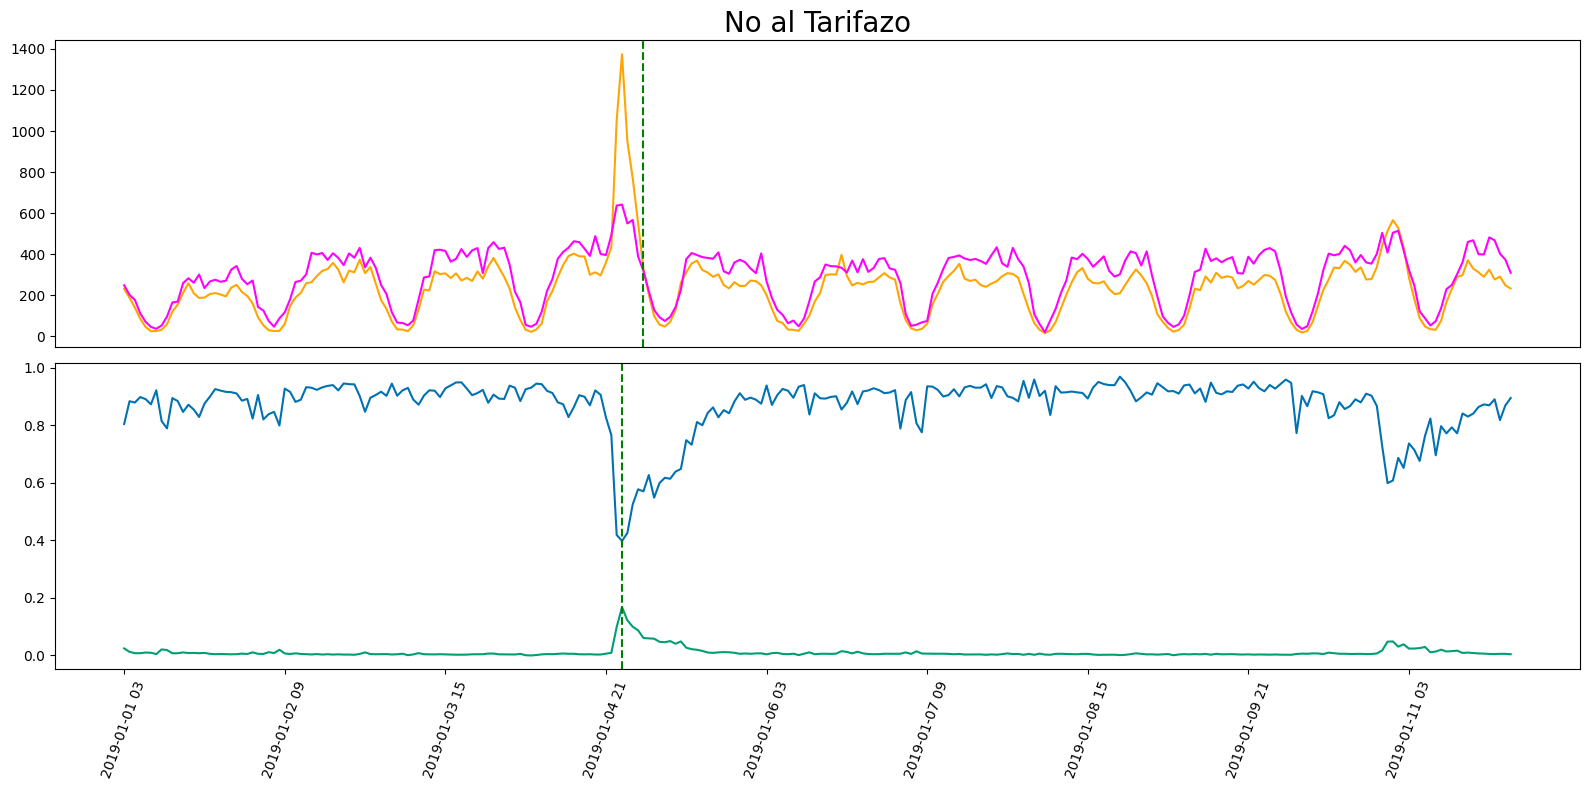

In [21]:
fig, axs = plt.subplots(2, 1)
axs = axs.flat
fig.set_size_inches(16,8)

for ax in axs:  # axs es una matriz, hay que aplanarla con .flat
	ax.set_facecolor("white")

plot_num_users_hashtags(axs[0], hour_nat_dt, hour_window_nat, num_users_nat, num_hashtags_nat, title="No al Tarifazo", inicio=0, legend=False, HORA_CRITICA="429628")
plot_mod_nestedness(axs[1], hour_nat_dt, hour_window_nat, mod_sort_nat_b, nest_sort_nat_b, inicio=0, legend=False, tick_split=30, HORA_CRITICA=HORA_CRITICA_NAT)

"""plot_num_users_hashtags(axs[1], hour_9n_dt, hour_window_9n, num_users_9n, num_hashtags_9n, title="9n", inicio=0, legend=False, HORA_CRITICA=HORA_CRITICA_9N)
plot_mod_nestedness(axs[5], hour_9n_dt, hour_window_9n, mod_sort_9n_b, nest_sort_9n_b, inicio=0, legend=False, tick_split=5, HORA_CRITICA=HORA_CRITICA_9N)

plot_num_users_hashtags(axs[2], hour_ch_dt, hour_window_ch, num_users_ch, num_hashtags_ch, title="Charlie Hebdo", inicio=lim_ch_und, legend=False, HORA_CRITICA=HORA_CRITICA_CH) 
plot_mod_nestedness(axs[6], hour_ch_dt, hour_window_ch, mod_sort_ch_b, nest_sort_ch_b, inicio=lim_ch_und, legend=False, tick_split=12, HORA_CRITICA=HORA_CRITICA_CH)

plot_num_users_hashtags(axs[3], hour_wd_dt, hour_window_wd, num_users_wd, num_hashtags_wd, title="Womanday", inicio=lim_wd_und, legend=False, HORA_CRITICA=HORA_CRITICA_WD)
plot_mod_nestedness(axs[7], hour_wd_dt, hour_window_wd, mod_sort_wd_b, nest_sort_wd_b, inicio=lim_wd_und, legend=True, tick_split=12, HORA_CRITICA=HORA_CRITICA_WD)

"""

plt.tight_layout()
plt.savefig(plots_folder + "num_unique_users_coef_mod.png")
plt.show()


## Función de Distribución de Probabilidad (PDF) y Función de Distribución Cumulativa Complementaria (CCDF) de las horas críticas

In [16]:
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, read=False)
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)
plfit_ch, arr_pdf_points_ch, arr_ccdf_points_ch = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)
plfit_wd, arr_pdf_points_wd, arr_ccdf_points_wd = calc_degree_distribution(HORA_CRITICA_WD, "wd/" + str(hour_window_wd) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

100%|██████████| 1/1 [00:00<00:00, 94.79it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 31068.92it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 16131.94it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 39568.91it/s]

Calculating best minimal value for power law fit


# AUTOSIMILITUD EN LAS REDES

## Grado medio por Kt

In [42]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat_h = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_9n_h = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_ch_h = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_wd_h = get_dict_hora_kt("wd", HORA_CRITICA_WD, hour_window=hour_window_wd, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

 36%|███▌      | 72/200 [00:00<00:00, 1292.72it/s]


## Autosimilitud

In [43]:
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')
dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/')

 36%|███▌      | 72/200 [00:00<00:00, 341.60it/s]


In [48]:
limit_kt_nat_h = 35
limit_kt_9n_h = 60
limit_kt_ch_h = 25
limit_kt_wd_h = 18

arr_kt_plot_nat_h = [0,2,4,8,9,10]
arr_kt_plot_9n_h = [0,10,15,20,25,30,35,40]
arr_kt_plot_ch_h = [0,7,9,11,13,15]
#arr_kt_plot_ch = [5]
arr_kt_plot_wd_h = [0,4,6,8,10,12]

#arr_kt_plot_nat_h = [0]
#arr_kt_plot_9n_h = [0]
#arr_kt_plot_ch_h = [0]
#arr_kt_plot_ch = [5]
#arr_kt_plot_wd = [0,4,6,8,10,12]arr_ccdf_points_ch_f

In [49]:
plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat_h, exp=False, norm=True)
plfit_9n_h, arr_pdf_points_9n_h, arr_ccdf_points_9n_h = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n_h, exp=False, norm=True)
plfit_ch_h, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True)
plfit_wd_h, arr_pdf_points_wd_h, arr_ccdf_points_wd_h = calc_degree_distribution(HORA_CRITICA_WD,  "wd/" + str(hour_window_wd) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_wd_h, exp=False, norm=True)

100%|██████████| 6/6 [00:00<00:00, 25445.73it/s]


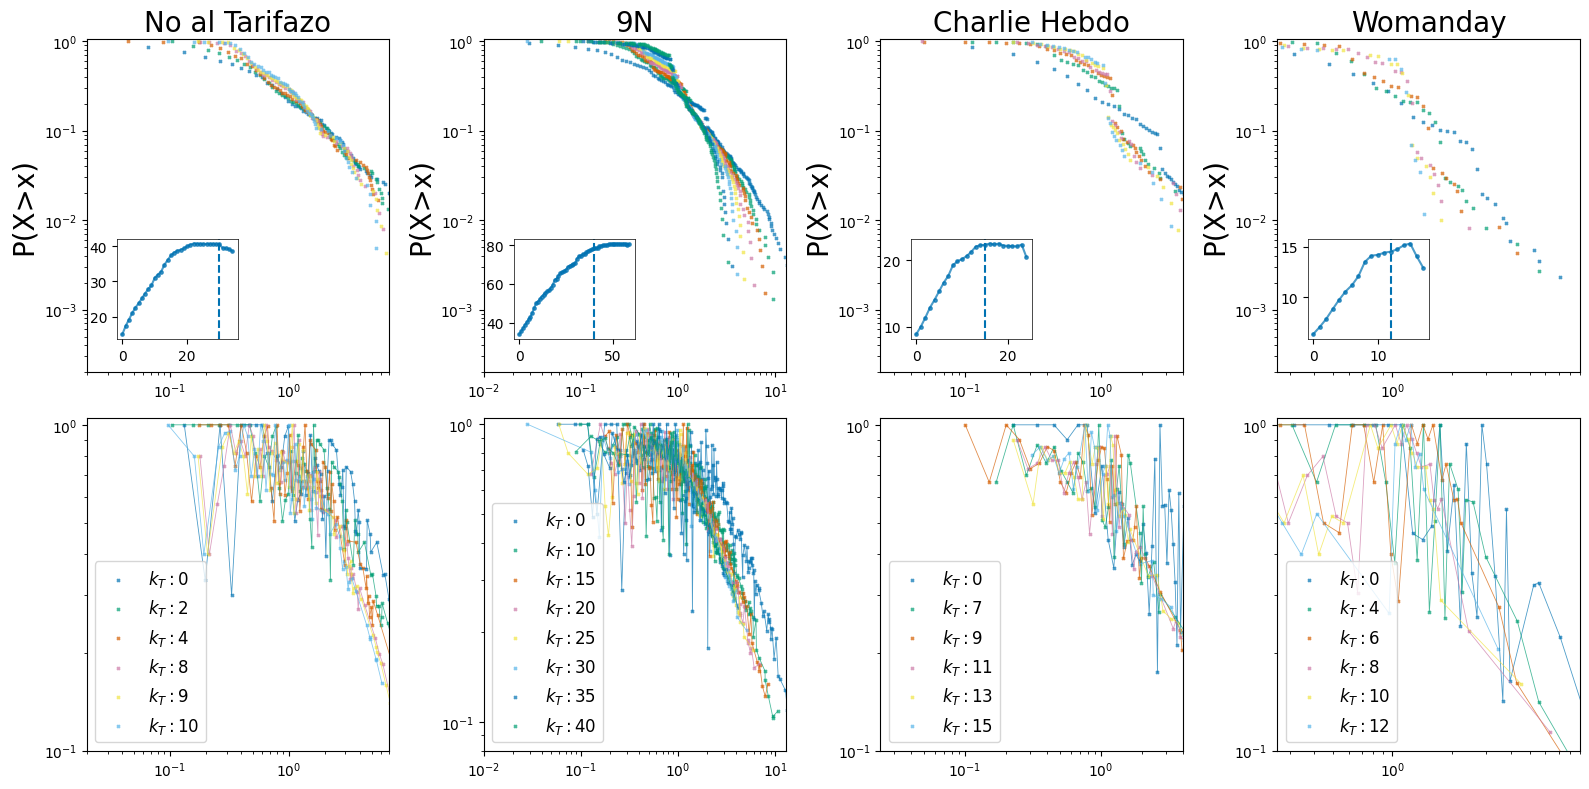

In [ ]:

fig, axs = plt.subplots(2, 4)
fig.set_size_inches(16,8)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")

xlim_nat = (0.02, 7)
xlim_9n = (0.01, 13)
xlim_ch = (0.024, 4)
xlim_wd = (0.26, 9)

plot_pdf(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h, title="No al Tarifazo", ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=30)

plot_pdf(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h, title="9N", ylim=(0.0002, 1.05), xlim=xlim_9n)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=40)

plot_pdf(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h, title="Charlie Hebdo", ylim=(0.0002, 1.05), xlim=xlim_ch)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=15)

plot_pdf(axs[3], arr_ccdf_points_wd_h, arr_kt_plot_wd_h, title="Womanday", ylim=(0.0002, 1.05), xlim=xlim_wd)
ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_hora_wd_h, limit_kt_wd_h, axvline=12)



plot_clust_ss(axs[4], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h, xlim=xlim_nat, ylim=(0.1, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h, xlim=xlim_9n, ylim=(0.08, 1.05))
plot_clust_ss(axs[6], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h, xlim=xlim_ch, ylim=(0.1, 1.05))
plot_clust_ss(axs[7], arr_kt_plot_wd_h, dict_norm_int_deg_wd_h, xlim=xlim_wd, ylim=(0.1, 1.05))



plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper.png")
plt.show()

## SS en multiples horas (NAT)

In [64]:
horas_nat = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]

arr_kt_plot_nat_h = [0,2,4,6,8,10]
MAX_UMBRAL = 200

In [ ]:
arr_dicts_avg_clust_nat = []
arr_dicts_norm_int_deg_nat = []
arr_ccdfs_points_nat = []
arr_dicts_hora_nat = []
arr_dicts_thres_avg_clust_nat_h = []
for hora in horas_nat:
	dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
	plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_h,read=False, exp=False, norm=True)
	dict_hora_nat_h = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat.append(dict_thres_avg_clust_nat_h)
	arr_dicts_norm_int_deg_nat.append(dict_norm_int_deg_nat_h)
	arr_ccdfs_points_nat.append(arr_ccdf_points_nat_h)
	arr_dicts_hora_nat.append(dict_hora_nat_h)

  0%|          | 0/200 [00:00<?, ?it/s]

 48%|████▊     | 97/200 [00:00<00:00, 381.16it/s]


In [85]:
limit_kt_nat_h = 35
xlim_nat = (0.02, 30)

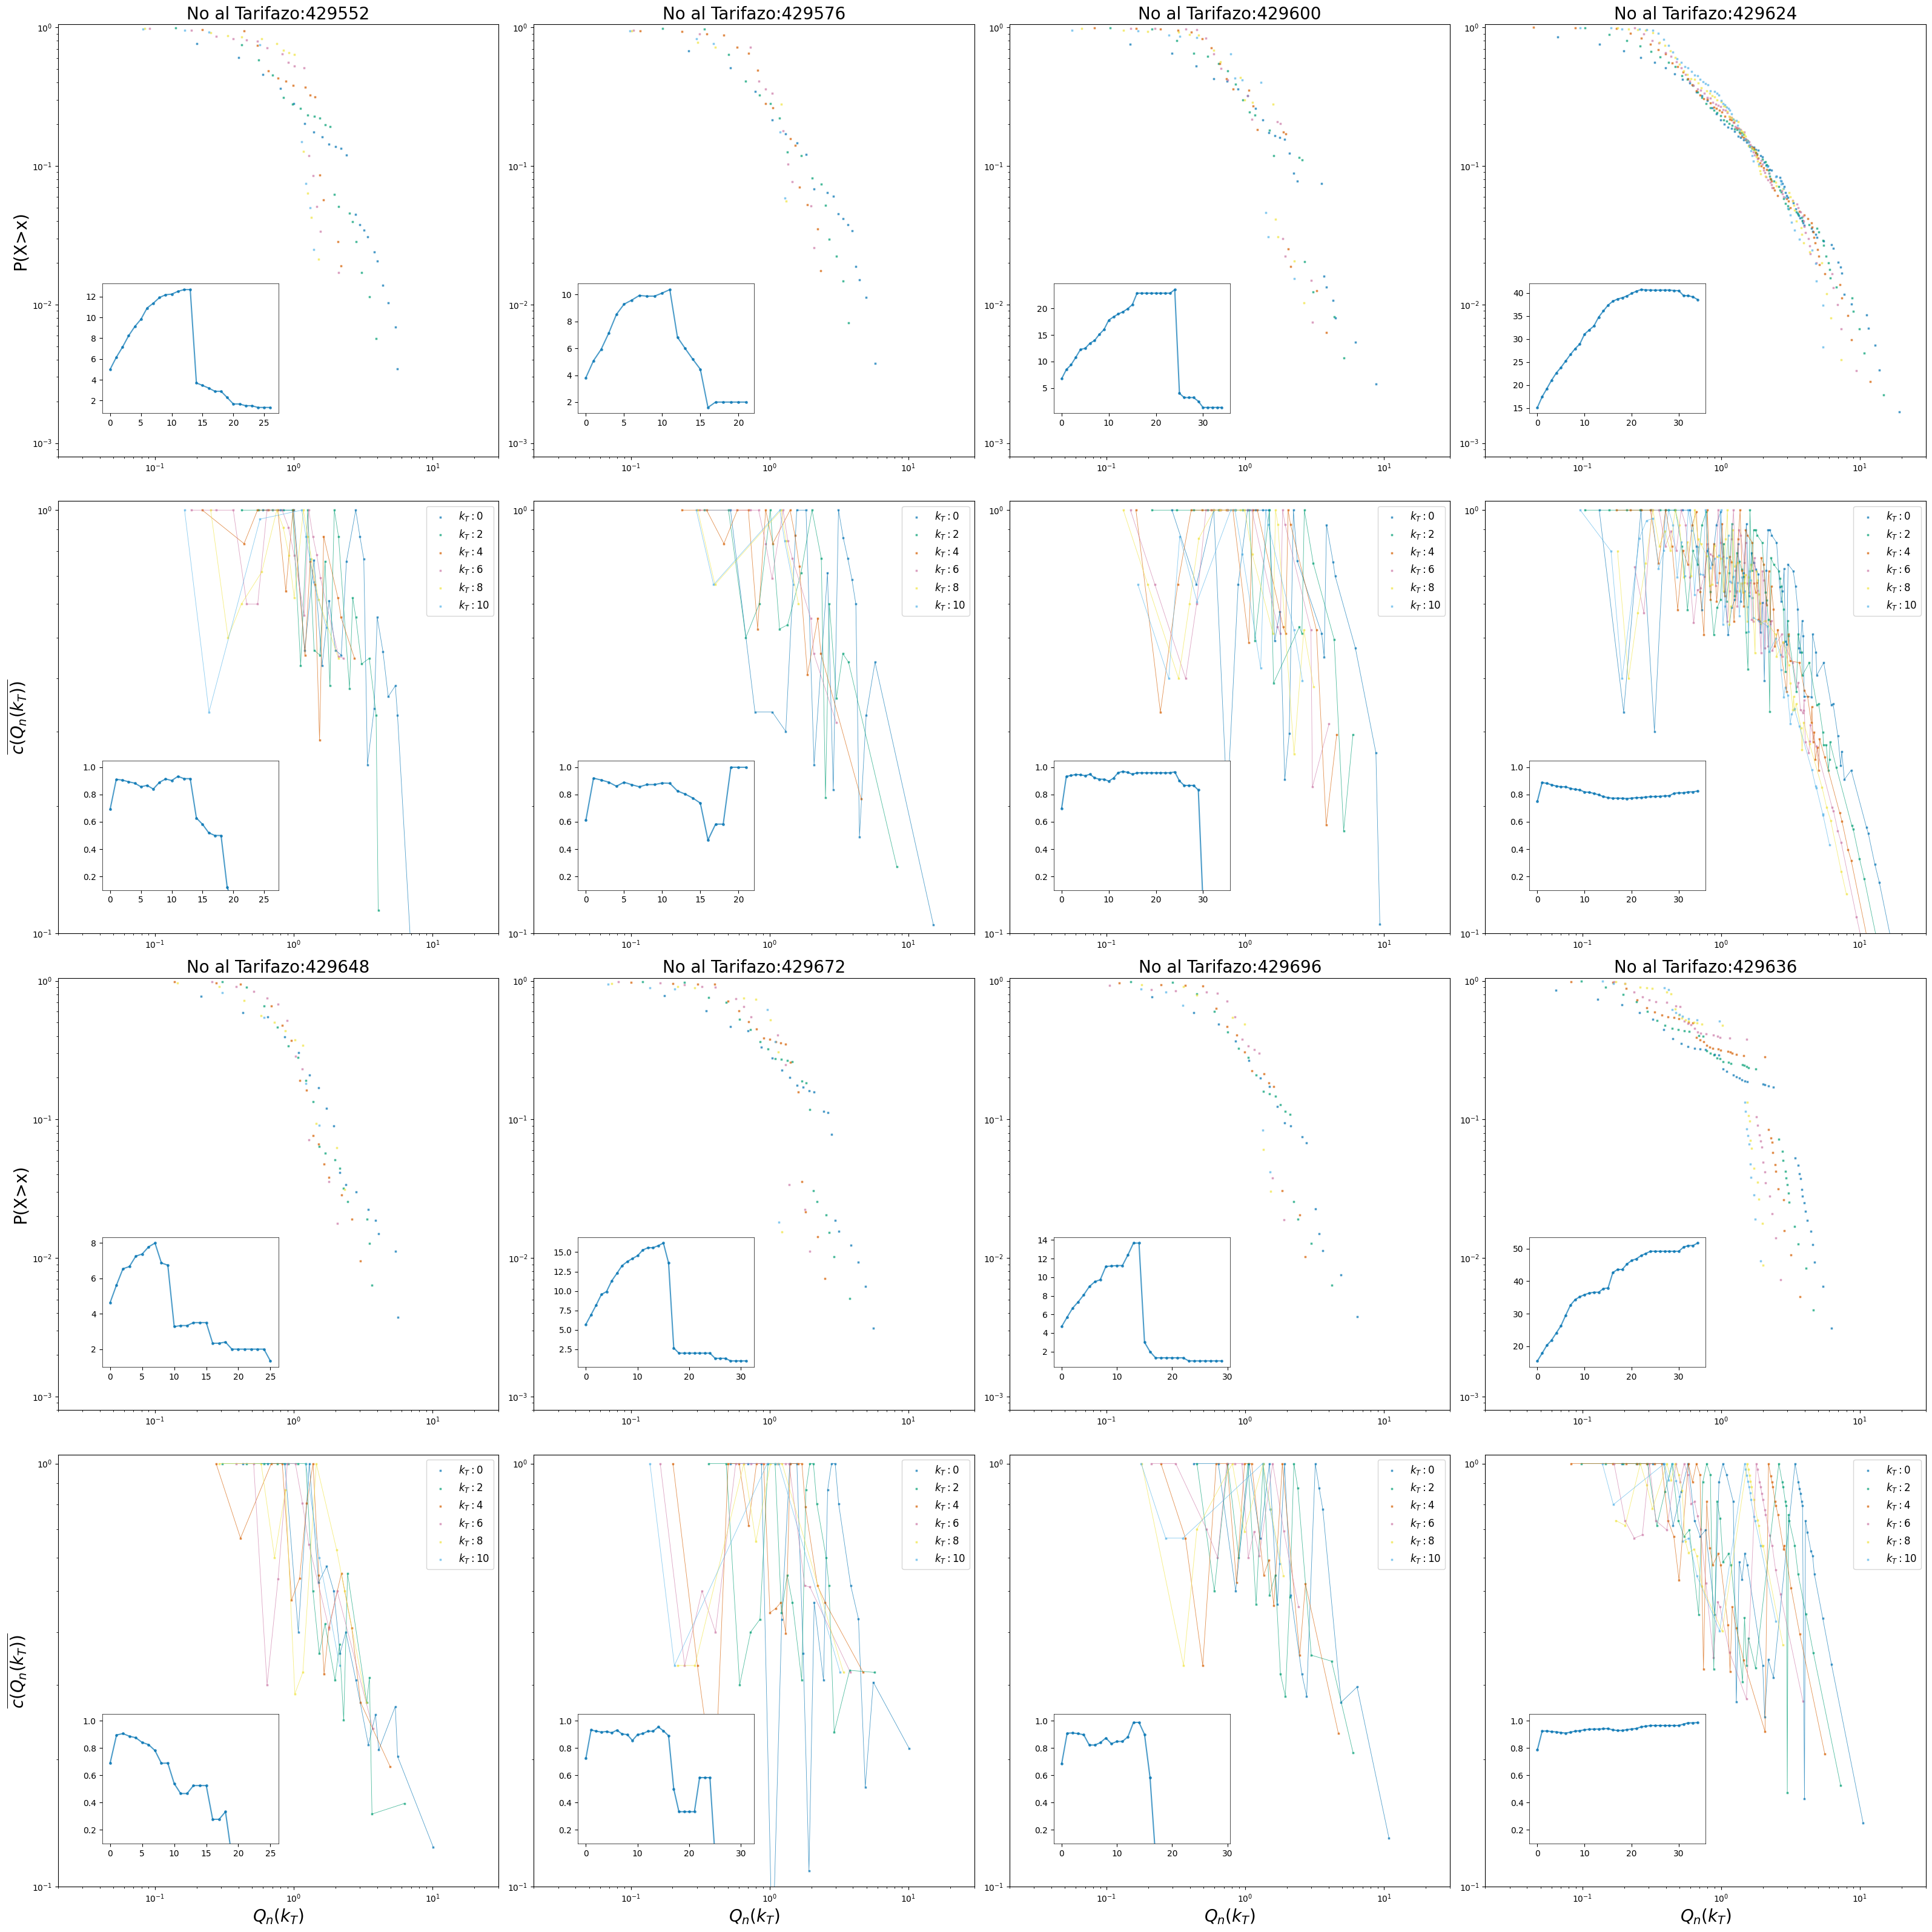

In [ ]:
fig, axs = plt.subplots(4, 4)
fig.set_size_inches(32,32)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")


for index, hora in enumerate(horas_nat):
	index_ax = (index // 4) * 8 + (index % 4)  
	plot_pdf(axs[index_ax], arr_ccdfs_points_nat[index], arr_kt_plot_nat_h, title=f"No al Tarifazo:{hora}", ylabel=None, ylim=(0.0008, 1.05), xlim=xlim_nat)
	ax0_inset = axs[index_ax].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax0_inset, arr_dicts_hora_nat[index], limit_kt_nat_h)


	plot_clust_ss(axs[index_ax + 4], arr_kt_plot_nat_h, arr_dicts_norm_int_deg_nat[index], xlim=xlim_nat, ylim=(0.1, 1.05))
	ax4_inset = axs[index_ax + 4].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax4_inset, arr_dicts_avg_clust_nat[index], limit_kt_nat_h, dot_size=6, ylim=(0.1, 1.05))

axs[0].set_ylabel("P(X>x)", fontsize=20)
axs[8].set_ylabel("P(X>x)", fontsize=20)
axs[4].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[12].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[12].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[13].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[14].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[15].set_xlabel("$Q_n(k_T)$", fontsize=20)

plt.tight_layout()
plt.savefig(plots_folder + "mult_CCDF_degree_self_sim_paper.png")
plt.show()

## Uso de d-mercator

Los archivos de código relativos al uso de d-mercator se encuentran en la carpeta ```d-mercator/``` del presente repositorio.

## Grafos Filtrados

### Ajuste a ley de potencia de los grafos filtrados

In [5]:
# Threshold empleado para cada manifestacion
umbral_nat = 3
umbral_9n = 5
umbral_ch = 3
umbral_wd = 2

umbral_otro_nat = 1
umbral_otro_9n = 3
umbral_otro_ch = 2
umbral_otro_wd = 3

In [6]:
OTRA_HORA_NAT = "429600"
OTRA_HORA_9N = "437000"
OTRA_HORA_CH = "394628"
"""OTRA_HORA_WD = "422303"""

'OTRA_HORA_WD = "422303'

In [24]:
# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, graphs_folder, hour_window_ch)
"""write_filtered_graph("wd", HORA_CRITICA_WD, umbral_wd, hour_window_wd)"""

Grafo nat:429624  (umbral 3) reducido a 19.16 % en nodos y  16.85 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos y  7.4 % en aristas.


'write_filtered_graph("wd", HORA_CRITICA_WD, umbral_wd, hour_window_wd)'

In [14]:
umbral_9n=5

In [3]:
write_filtered_graph("9n", "437037", 1, graphs_folder, hour_window_9n)

Grafo 9n:437037  (umbral 1) reducido a 92.39 % en nodos y  99.71 % en aristas.


In [15]:
# CREACIÓN DE LOS GRAFOS FILTRADOS DE OTRAS HORAS NO CRITICAS
write_filtered_graph("nat", OTRA_HORA_NAT, umbral_otro_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", OTRA_HORA_9N, umbral_otro_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", OTRA_HORA_CH, umbral_otro_ch, graphs_folder, hour_window_ch)
"""write_filtered_graph("wd", OTRA_HORA_WD, umbral_otro_wd, hour_window_wd)"""

Grafo nat:429600  (umbral 1) reducido a 47.71 % en nodos y  79.71 % en aristas.
Grafo 9n:437000  (umbral 3) reducido a 9.13 % en nodos y  2.67 % en aristas.
Grafo ch:394628  (umbral 2) reducido a 25.64 % en nodos y  26.46 % en aristas.


'write_filtered_graph("wd", OTRA_HORA_WD, umbral_otro_wd, hour_window_wd)'

### Grado medio por kt

In [16]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200
dict_hora_nat_f = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat)
dict_hora_9n_f = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n)
dict_hora_ch_f = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)
#dict_hora_wd_f = get_dict_hora_kt("wd", HORA_CRITICA_WD, hour_window=hour_window_wd, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL)

 19%|█▉        | 38/200 [00:00<00:00, 7605.99it/s]


In [17]:
limit_kt_nat_f = 35
limit_kt_9n_f = 60
limit_kt_ch_f = 30
#limit_kt_wd = 18

critical_kt_nat_f = 10
critical_kt_9n_f = 18
critical_kt_ch_f = 5
#critical_kt_wd = 7

arr_kt_plot_nat_f = [0,4,6,8,10]
arr_kt_plot_9n_f = [0,6,9,12,15,18]
arr_kt_plot_ch_f = [0,1,2,3,4,5]
arr_kt_plot_wd_f = [0,1,2,3,4,5,6,7]


critical_otra_kt_nat = 10
critical_otra_kt_9n = 18
critical_otra_kt_ch = 5

arr_otra_kt_plot_nat = [0,3,6,9,12,15,18]
arr_otra_kt_plot_9n = [0,1,2,3,4,5]
arr_otra_kt_plot_ch =  [0,2,4,6,8,10]

In [ ]:
plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True)
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True)
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True)

plfit_otra_nat_f, arr_pdf_points_otra_nat_f, arr_ccdf_points_otra_nat_f = calc_degree_distribution(OTRA_HORA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_nat, thresh_filt=umbral_otro_nat, norm=True)
plfit_otra_9n_f, arr_pdf_points_otra_9n_f, arr_ccdf_points_otra_9n_f = calc_degree_distribution(OTRA_HORA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_9n, thresh_filt=umbral_otro_9n, norm=True)
plfit_otra_ch_f, arr_pdf_points_otra_ch_f, arr_ccdf_points_otra_ch_f = calc_degree_distribution(OTRA_HORA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_ch, thresh_filt=umbral_otro_ch, norm=True)

100%|██████████| 5/5 [00:00<00:00, 24995.85it/s]

Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 20443.40it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 15391.94it/s]


...

Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 40329.85it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 27594.11it/s]

Calculating best minimal value for power law fit


### Autosimilitud de redes filtradas y Resultados en otras ventanas temporales diferentes a la crítica

In [ ]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h_f, dict_norm_int_deg_nat_h_f = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_h_f, dict_norm_int_deg_9n_h_f = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_h_f, dict_norm_int_deg_ch_h_f = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)
"""dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/', mode="f", thresh_filter=umbral_wd)"""


dict_thres_avg_clust_otra_nat_h_f, dict_norm_int_deg_otra_nat_h_f = calc_self_sim(OTRA_HORA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_otro_nat)
dict_thres_avg_clust_otra_9n_h_f, dict_norm_int_deg_otra_9n_h_f = calc_self_sim(OTRA_HORA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_otro_9n)
dict_thres_avg_clust_otra_ch_h_f, dict_norm_int_deg_otra_ch_h_f = calc_self_sim(OTRA_HORA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_otro_ch)
#dict_thres_avg_clust_otra_wd_h, dict_norm_int_deg_otra_wd_h = calc_self_sim(OTRA_HORA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/', mode="f", thresh_filter=umbral_otro_wd)

  0%|          | 0/500 [00:00<?, ?it/s]

 30%|███       | 151/500 [00:00<00:00, 517.61it/s]


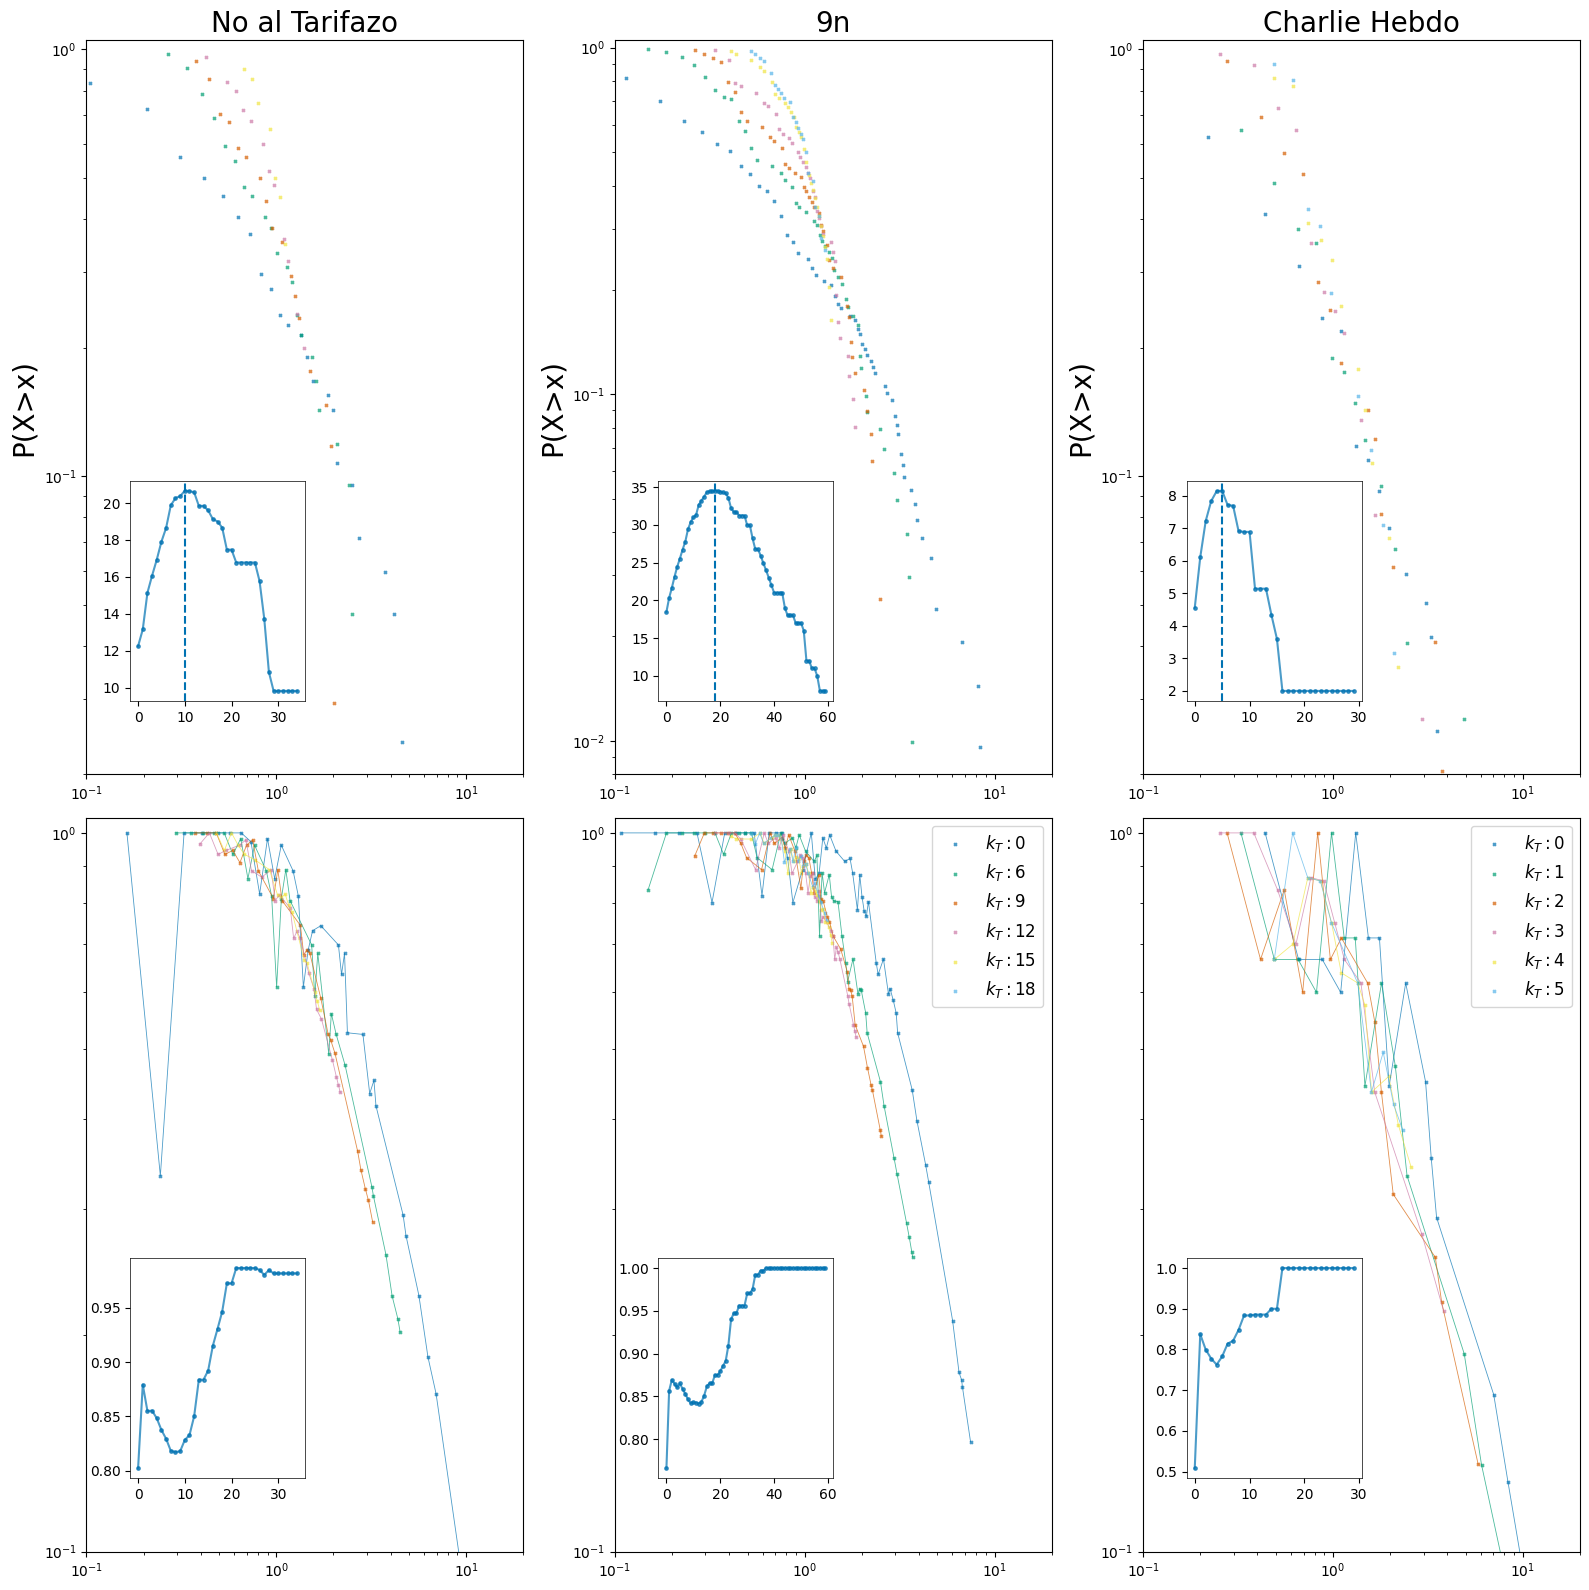

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,16)

xlim_nat_f = (0.1, 20)
xlim_9n_f = (0.1, 20)
xlim_ch_f = (0.1, 20)
xlim_wd_f = (0.1, 20)

xlim_otra_nat_f = (0.1, 10)
xlim_otra_9n_f = (0.1, 20)
xlim_otra_ch_f = (0.1, 20)
xlim_otra_wd_f = (0.1, 20)

array_puntos_plfit = []

plot_pdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, title="No al Tarifazo", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim=xlim_nat_f)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f, title="9n", ylim=(0.008, 1.05), xlim=xlim_9n_f)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f, title="Charlie Hebdo", ylim=(0.02, 1.05), xlim=xlim_ch_f)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_h_f, xlim=xlim_nat_f, ylim=(0.1, 1.05), legend=False)
ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_h_f, limit_kt_nat_f, dot_size=6)

plot_clust_ss(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_h_f, xlim=xlim_9n_f, ylim=(0.1, 1.05))
ax4_inset = axs[4].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax4_inset, dict_thres_avg_clust_9n_h_f, limit_kt_9n_f, dot_size=6)

plot_clust_ss(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_h_f, xlim=xlim_ch_f, ylim=(0.1, 1.05))
ax5_inset = axs[5].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax5_inset, dict_thres_avg_clust_ch_h_f, limit_kt_ch_f, dot_size=6)


plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

In [ ]:
horas_nat = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]

arr_kt_plot_nat_f = [0,2,4,6,8,10]
MAX_UMBRAL = 200

In [ ]:
arr_dicts_avg_clust_nat = []
arr_dicts_norm_int_deg_nat = []
arr_ccdfs_points_nat = []
arr_dicts_hora_nat = []
arr_dicts_thres_avg_clust_nat_f = []
for hora in horas_nat:
	dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
	plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_h,read=False, exp=False, norm=True)
	dict_hora_nat_h = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat.append(dict_thres_avg_clust_nat_h)
	arr_dicts_norm_int_deg_nat.append(dict_norm_int_deg_nat_h)
	arr_ccdfs_points_nat.append(arr_ccdf_points_nat_h)
	arr_dicts_hora_nat.append(dict_hora_nat_h)

In [ ]:
fig, axs = plt.subplots(4, 4)
fig.set_size_inches(32,32)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")


for index, hora in enumerate(horas_nat):
	index_ax = (index // 4) * 8 + (index % 4)  
	plot_pdf(axs[index_ax], arr_ccdfs_points_nat[index], arr_kt_plot_nat_h, title=f"No al Tarifazo:{hora}", ylabel=None, ylim=(0.0008, 1.05), xlim=xlim_nat)
	ax0_inset = axs[index_ax].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax0_inset, arr_dicts_hora_nat[index], limit_kt_nat_h)


	plot_clust_ss(axs[index_ax + 4], arr_kt_plot_nat_h, arr_dicts_norm_int_deg_nat[index], xlim=xlim_nat, ylim=(0.1, 1.05))
	ax4_inset = axs[index_ax + 4].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax4_inset, arr_dicts_avg_clust_nat[index], limit_kt_nat_h, dot_size=6, ylim=(0.1, 1.05))

axs[0].set_ylabel("P(X>x)", fontsize=20)
axs[8].set_ylabel("P(X>x)", fontsize=20)
axs[4].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[12].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[12].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[13].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[14].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[15].set_xlabel("$Q_n(k_T)$", fontsize=20)

plt.tight_layout()
plt.savefig(plots_folder + "mult_CCDF_degree_self_sim_paper.png")
plt.show()

NameError: name 'dict_otra_hora_nat_f' is not defined

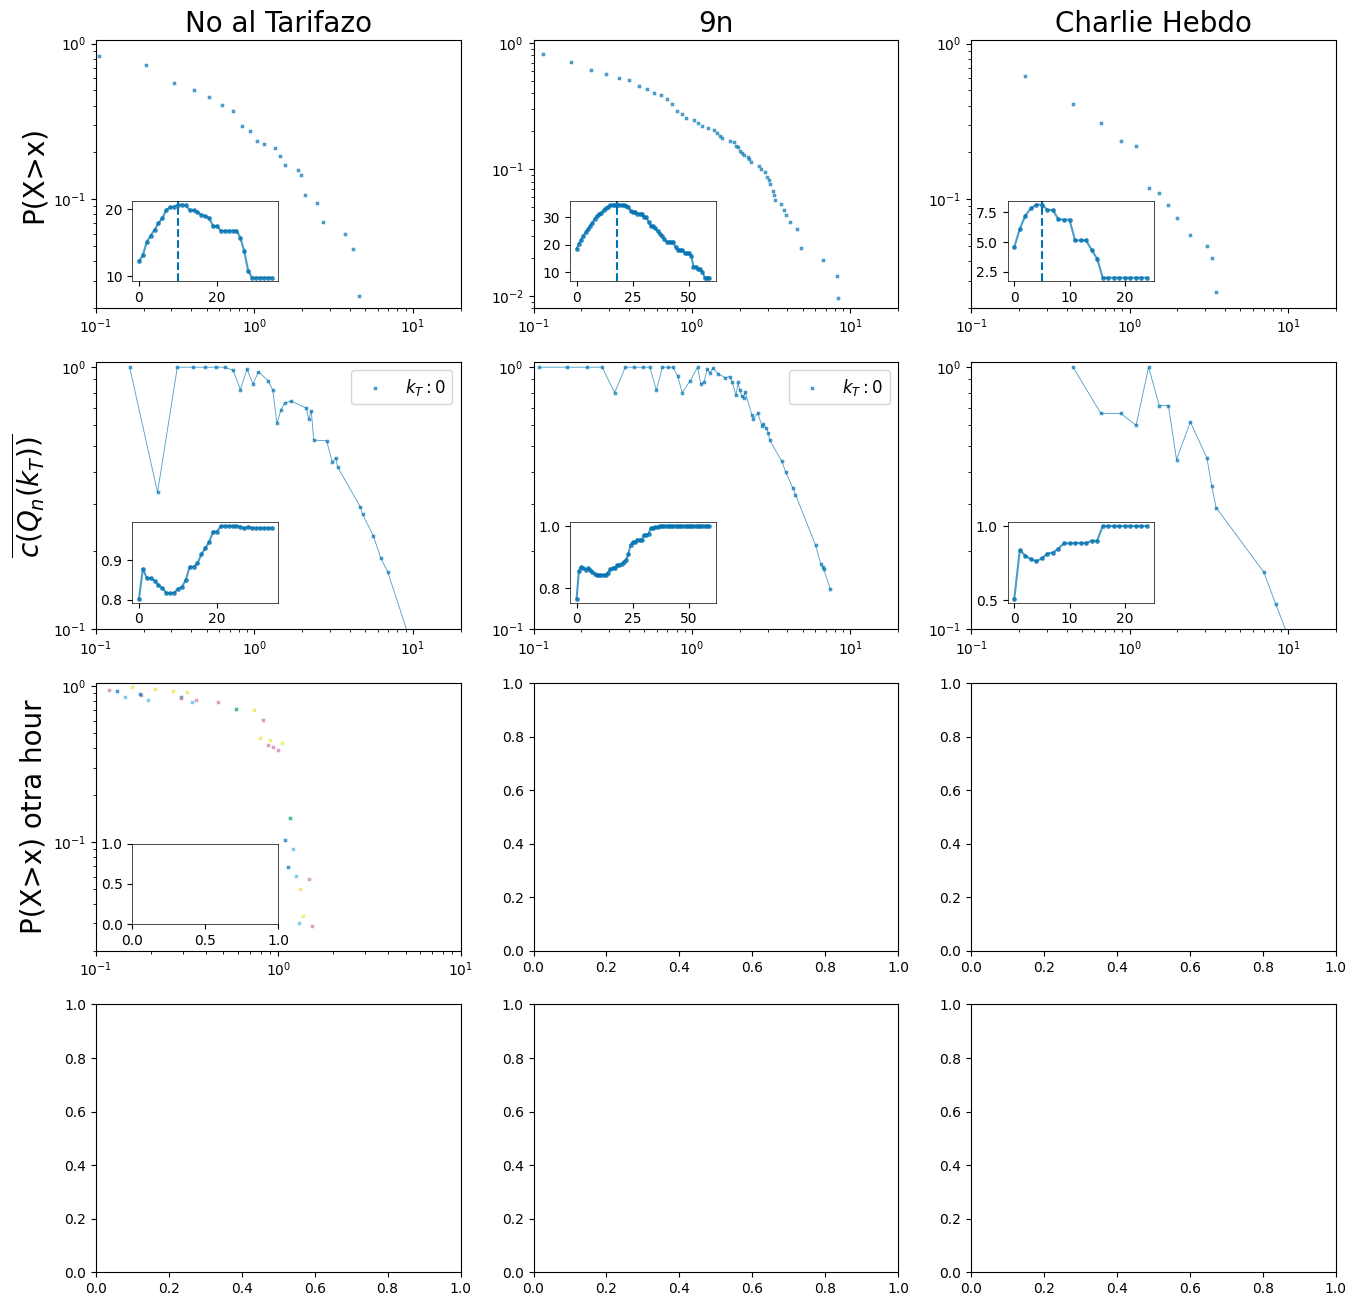

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,16)

xlim_nat = (0.1, 20)
xlim_9n = (0.1, 20)
xlim_ch = (0.1, 20)
xlim_wd = (0.1, 20)

xlim_otra_nat = (0.1, 10)
xlim_otra_9n = (0.1, 20)
xlim_otra_ch = (0.1, 20)
xlim_otra_wd = (0.1, 20)


dot_size=4
marker = "" \
"x"
alpha=0.7

array_puntos_plfit = []

for index, points in enumerate(arr_ccdf_points_nat_f):
	axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot_nat[index]))
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
axs[0].set_title("No al Tarifazo", fontsize=20)
axs[0].set_ylabel("P(X>x)", fontsize=20)


ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax0_inset)
ax0_inset.plot(list(dict_hora_nat_f.keys())[0:limit_kt_nat], list(dict_hora_nat_f.values())[0:limit_kt_nat], alpha=alpha)
ax0_inset.scatter(list(dict_hora_nat_f.keys())[0:limit_kt_nat], list(dict_hora_nat_f.values())[0:limit_kt_nat], s=6, alpha=alpha)
ax0_inset.axvline(critical_kt_nat_f, ls="--")

for index, points in enumerate(arr_ccdf_points_9n_f):
	axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot_9n[index]))
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.008, 1.05)
axs[1].set_xlim(xlim_9n[0], xlim_9n[1])
axs[1].set_title("9n", fontsize=20)

ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax1_inset)
ax1_inset.plot(list(dict_hora_9n_f.keys())[0:limit_kt_9n], list(dict_hora_9n_f.values())[0:limit_kt_9n], alpha=alpha)
ax1_inset.scatter(list(dict_hora_9n_f.keys())[0:limit_kt_9n], list(dict_hora_9n_f.values())[0:limit_kt_9n], s=6, alpha=alpha)
ax1_inset.axvline(critical_kt_9n_f, ls="--")

for index, points in enumerate(arr_ccdf_points_ch_f):
	axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot_ch[index]))
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_xlim(xlim_ch[0], xlim_ch[1])
axs[2].set_title("Charlie Hebdo", fontsize=20)

ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax2_inset)
ax2_inset.plot(list(dict_hora_ch_f.keys())[0:limit_kt_ch], list(dict_hora_ch_f.values())[0:limit_kt_ch], alpha=alpha)
ax2_inset.scatter(list(dict_hora_ch_f.keys())[0:limit_kt_ch], list(dict_hora_ch_f.values())[0:limit_kt_ch], s=6, alpha=alpha)
ax2_inset.axvline(critical_kt_ch_f, ls="--")


for index, kt in enumerate(arr_kt_plot_nat[:]):
	if kt in dict_norm_int_deg_nat_h_f.keys():
		points_x = list(dict_norm_int_deg_nat_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_nat_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_nat_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[3].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[3].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[3].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[3].set_xscale('log')  
axs[3].set_yscale('log')      
axs[3].set_ylim(0.1, 1.05)
axs[3].set_xlim(xlim_nat[0], xlim_nat[1])

ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax3_inset)
ax3_inset.plot(list(dict_thres_avg_clust_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_nat_h_f.values())[0:limit_kt_nat], alpha=alpha)
ax3_inset.scatter(list(dict_thres_avg_clust_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_nat_h_f.values())[0:limit_kt_nat], s=6, alpha=alpha)

#axs[3].legend(loc="lower left", prop={'size': 12})
axs[3].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_9n[:]):
	if kt in dict_norm_int_deg_9n_h_f.keys():
		points_x = list(dict_norm_int_deg_9n_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_9n_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_9n_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[4].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[4].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[4].set_xscale('log')  
axs[4].set_yscale('log')      
axs[4].set_ylim(0.1, 1.05)
axs[4].set_xlim(xlim_9n[0], xlim_9n[1])

ax4_inset = axs[4].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax4_inset)
ax4_inset.plot(list(dict_thres_avg_clust_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_9n_h_f.values())[0:limit_kt_9n], alpha=alpha)
ax4_inset.scatter(list(dict_thres_avg_clust_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_9n_h_f.values())[0:limit_kt_9n], s=6, alpha=alpha)

#axs[4].legend(loc="lower left", prop={'size': 12})
axs[4].legend(prop={'size': 12})




for index, kt in enumerate(arr_kt_plot_ch[:]):
	if kt in dict_norm_int_deg_ch_h_f.keys():
		points_x = list(dict_norm_int_deg_ch_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_ch_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_ch_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[5].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[5].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[5].set_xscale('log')  
axs[5].set_yscale('log')          
axs[5].set_ylim(0.1, 1.05)
axs[5].set_xlim(xlim_ch[0], xlim_ch[1])

ax5_inset = axs[5].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax5_inset)
ax5_inset.plot(list(dict_thres_avg_clust_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_ch_h_f.values())[0:limit_kt_ch], alpha=alpha)
ax5_inset.scatter(list(dict_thres_avg_clust_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_ch_h_f.values())[0:limit_kt_ch], s=6, alpha=alpha)

#axs[5].legend(loc="lower left", prop={'size': 12})
axs[4].legend(prop={'size': 12})


for index, points in enumerate(arr_ccdf_points_otra_nat_f):
	axs[6].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_nat[index]))
axs[6].set_xscale('log')
axs[6].set_yscale('log')
axs[6].set_ylim(0.02, 1.05)
axs[6].set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
axs[6].set_ylabel("P(X>x) otra hour", fontsize=20)


ax6_inset = axs[6].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax6_inset)
ax6_inset.plot(list(dict_otra_hora_nat_f.keys())[0:limit_kt_nat], list(dict_otra_hora_nat_f.values())[0:limit_kt_nat], alpha=alpha)
ax6_inset.scatter(list(dict_otra_hora_nat_f.keys())[0:limit_kt_nat], list(dict_otra_hora_nat_f.values())[0:limit_kt_nat], s=6, alpha=alpha)
#ax6_inset.axvline(critical_otra_kt_nat, ls="--")

for index, points in enumerate(arr_ccdf_points_otra_9n_f):
	axs[7].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_9n[index]))
axs[7].set_xscale('log')
axs[7].set_yscale('log')
axs[7].set_ylim(0.008, 1.05)
axs[7].set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])
ax7_inset = axs[7].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax7_inset)
ax7_inset.plot(list(dict_otra_hora_9n_f.keys())[0:limit_kt_9n], list(dict_otra_hora_9n_f.values())[0:limit_kt_9n], alpha=alpha)
ax7_inset.scatter(list(dict_otra_hora_9n_f.keys())[0:limit_kt_9n], list(dict_otra_hora_9n_f.values())[0:limit_kt_9n], s=6, alpha=alpha)
#ax7_inset.axvline(critical_otra_kt_9n, ls="--")

for index, points in enumerate(arr_ccdf_points_otra_ch_f):
	axs[8].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_ch[index]))
axs[8].set_xscale('log')
axs[8].set_yscale('log')
axs[8].set_ylim(0.001, 1.05)
axs[8].set_xlim(xlim_otra_ch[0], 100)
ax8_inset = axs[8].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax8_inset)
ax8_inset.plot(list(dict_otra_hora_ch_f.keys())[0:limit_kt_ch], list(dict_otra_hora_ch_f.values())[0:limit_kt_ch], alpha=alpha)
ax8_inset.scatter(list(dict_otra_hora_ch_f.keys())[0:limit_kt_ch], list(dict_otra_hora_ch_f.values())[0:limit_kt_ch], s=6, alpha=alpha)
#ax8_inset.axvline(critical_otra_kt_ch, ls="--")


for index, kt in enumerate(arr_otra_kt_plot_nat[:]):
	if kt in dict_norm_int_deg_otra_nat_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_nat_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_nat_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_nat_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[9].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[9].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[9].set_ylabel("$\\overline{c(Q_n(k_T))}$ otra hour ", fontsize=20)
axs[9].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[9].set_xscale('log')  
axs[9].set_yscale('log')      
axs[9].set_ylim(0.01, 1.05)
axs[9].set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
axs[9].legend(prop={'size': 12})

ax9_inset = axs[9].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax9_inset)
ax9_inset.plot(list(dict_thres_avg_clust_otra_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_otra_nat_h_f.values())[0:limit_kt_nat], alpha=alpha)
ax9_inset.scatter(list(dict_thres_avg_clust_otra_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_otra_nat_h_f.values())[0:limit_kt_nat], s=6, alpha=alpha)

#axs[9].legend(loc="lower left", prop={'size': 12})
axs[9].legend(prop={'size': 12})


for index, kt in enumerate(arr_otra_kt_plot_9n[:]):
	if kt in dict_norm_int_deg_otra_9n_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_9n_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_9n_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_9n_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[10].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[10].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[10].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[10].set_xscale('log')  
axs[10].set_yscale('log')      
axs[10].set_ylim(0.1, 1.05)
axs[10].set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])


ax10_inset = axs[10].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax10_inset)
ax10_inset.plot(list(dict_thres_avg_clust_otra_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_otra_9n_h_f.values())[0:limit_kt_9n], alpha=alpha)
ax10_inset.scatter(list(dict_thres_avg_clust_otra_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_otra_9n_h_f.values())[0:limit_kt_9n], s=6, alpha=alpha)

#axs[10].legend(loc="lower left", prop={'size': 12})
axs[10].legend(prop={'size': 12})



for index, kt in enumerate(arr_otra_kt_plot_ch[:]):
	if kt in dict_norm_int_deg_otra_ch_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_ch_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_ch_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_ch_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[11].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[11].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[11].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[11].set_xscale('log')  
axs[11].set_yscale('log')          
axs[11].set_ylim(0.001, 1.05)
axs[11].set_xlim(xlim_otra_ch[0], 100)

ax11_inset = axs[11].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax11_inset)
ax11_inset.plot(list(dict_thres_avg_clust_otra_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_otra_ch_h_f.values())[0:limit_kt_ch], alpha=alpha)
ax11_inset.scatter(list(dict_thres_avg_clust_otra_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_otra_ch_h_f.values())[0:limit_kt_ch], s=6, alpha=alpha)

#axs[11].legend(loc="lower left", prop={'size': 12})
axs[11].legend(prop={'size': 12})



plt.tight_layout()
#plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

### Figura 1: 2x2:
	CCDF en inset CCDF de otra hora
	SS en inset SS de otra hora

### Figura 2: 2x2
	AVg degree por kt
	Clust promedio por kt

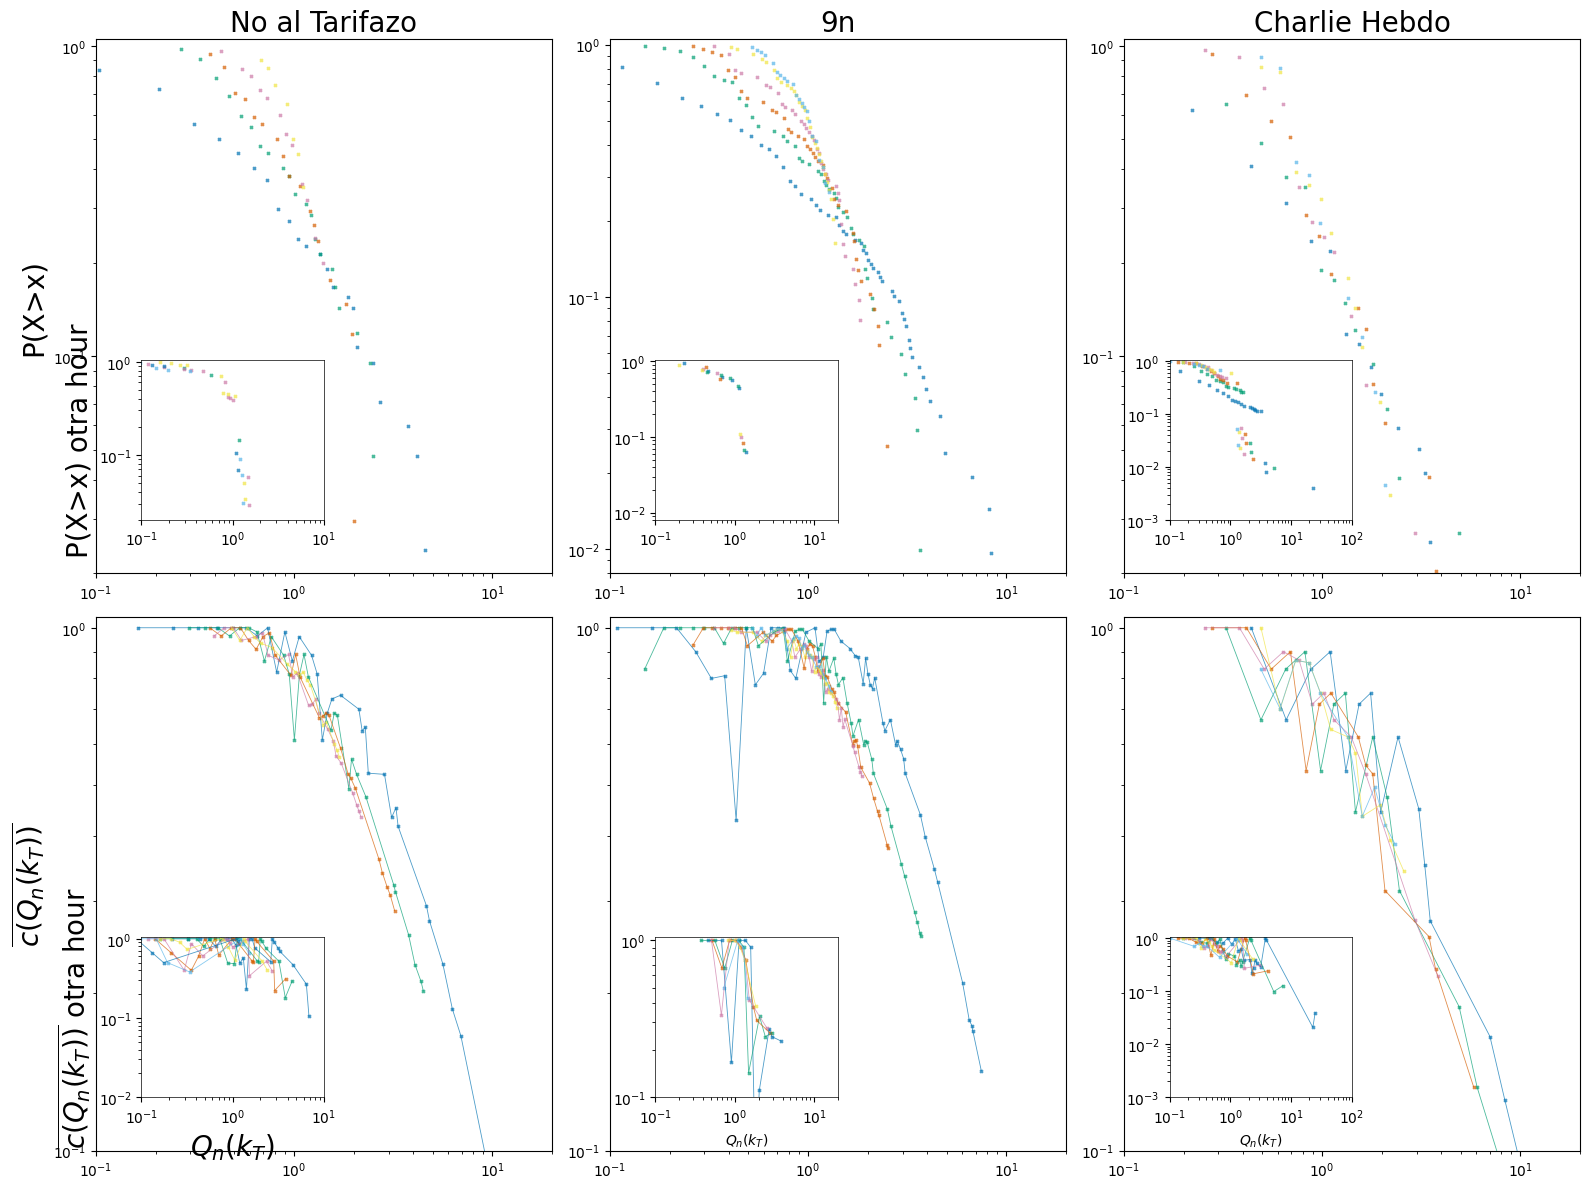

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat 
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,12)

xlim_nat = (0.1, 20)
xlim_9n = (0.1, 20)
xlim_ch = (0.1, 20)
xlim_wd = (0.1, 20)

xlim_otra_nat = (0.1, 10)
xlim_otra_9n = (0.1, 20)
xlim_otra_ch = (0.1, 20)
xlim_otra_wd = (0.1, 20)


dot_size=4
marker = "" \
"x"
alpha=0.7

array_puntos_plfit = []

for index, points in enumerate(arr_ccdf_points_nat_f):
	axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_T$ = " + str(arr_kt_plot_nat[index]))
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
axs[0].set_title("No al Tarifazo", fontsize=20)
axs[0].set_ylabel("P(X>x)", fontsize=20)


ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax0_inset)
for index, points in enumerate(arr_ccdf_points_otra_nat_f):
	ax0_inset.scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_nat[index]))
ax0_inset.set_xscale('log')
ax0_inset.set_yscale('log')
ax0_inset.set_ylim(0.02, 1.05)
ax0_inset.set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
ax0_inset.set_ylabel("P(X>x) otra hour", fontsize=20)


for index, points in enumerate(arr_ccdf_points_9n_f):
	axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot_9n[index]))
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.008, 1.05)
axs[1].set_xlim(xlim_9n[0], xlim_9n[1])
axs[1].set_title("9n", fontsize=20)

ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax1_inset)
for index, points in enumerate(arr_ccdf_points_otra_9n_f):
	ax1_inset.scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_9n[index]))
ax1_inset.set_xscale('log')
ax1_inset.set_yscale('log')
ax1_inset.set_ylim(0.008, 1.05)
ax1_inset.set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])


for index, points in enumerate(arr_ccdf_points_ch_f):
	axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot_ch[index]))
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_xlim(xlim_ch[0], xlim_ch[1])
axs[2].set_title("Charlie Hebdo", fontsize=20)

ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax2_inset)

for index, points in enumerate(arr_ccdf_points_otra_ch_f):
	ax2_inset.scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_otra_kt_plot_ch[index]))
ax2_inset.set_xscale('log')
ax2_inset.set_yscale('log')
ax2_inset.set_ylim(0.001, 1.05)
ax2_inset.set_xlim(xlim_otra_ch[0], 100)




for index, kt in enumerate(arr_kt_plot_nat[:]):
	if kt in dict_norm_int_deg_nat_h_f.keys():
		points_x = list(dict_norm_int_deg_nat_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_nat_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_nat_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[3].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[3].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[3].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[3].set_xscale('log')  
axs[3].set_yscale('log')      
axs[3].set_ylim(0.1, 1.05)
axs[3].set_xlim(xlim_nat[0], xlim_nat[1])

ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax3_inset)


for index, kt in enumerate(arr_otra_kt_plot_nat[:]):
	if kt in dict_norm_int_deg_otra_nat_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_nat_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_nat_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_nat_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		ax3_inset.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		ax3_inset.scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

ax3_inset.set_ylabel("$\\overline{c(Q_n(k_T))}$ otra hour ", fontsize=20)
ax3_inset.set_xlabel("$Q_n(k_T)$", fontsize=20)
ax3_inset.set_xscale('log')  
ax3_inset.set_yscale('log')      
ax3_inset.set_ylim(0.01, 1.05)
ax3_inset.set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
#ax3_inset.legend(prop={'size': 12})



for index, kt in enumerate(arr_kt_plot_9n[:]):
	if kt in dict_norm_int_deg_9n_h_f.keys():
		points_x = list(dict_norm_int_deg_9n_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_9n_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_9n_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[4].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[4].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[4].set_xscale('log')  
axs[4].set_yscale('log')      
axs[4].set_ylim(0.1, 1.05)
axs[4].set_xlim(xlim_9n[0], xlim_9n[1])

ax4_inset = axs[4].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax4_inset)

for index, kt in enumerate(arr_otra_kt_plot_9n[:]):
	if kt in dict_norm_int_deg_otra_9n_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_9n_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_9n_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_9n_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		ax4_inset.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		ax4_inset.scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

ax4_inset.set_xlabel("$Q_n(k_T$)", fontsize=10)
ax4_inset.set_xscale('log')  
ax4_inset.set_yscale('log')      
ax4_inset.set_ylim(0.1, 1.05)
ax4_inset.set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])
 





for index, kt in enumerate(arr_kt_plot_ch[:]):
	if kt in dict_norm_int_deg_ch_h_f.keys():
		points_x = list(dict_norm_int_deg_ch_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_ch_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_ch_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		axs[5].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		axs[5].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[5].set_xscale('log')  
axs[5].set_yscale('log')          
axs[5].set_ylim(0.1, 1.05)
axs[5].set_xlim(xlim_ch[0], xlim_ch[1])

ax5_inset = axs[5].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax5_inset)


for index, kt in enumerate(arr_otra_kt_plot_ch[:]):
	if kt in dict_norm_int_deg_otra_ch_h_f.keys():
		points_x = list(dict_norm_int_deg_otra_ch_h_f[kt].keys())[::]
		points_y = list(dict_norm_int_deg_otra_ch_h_f[kt].values())[::]
		# Se quita el 0 para que la visualizacións se más clara
		if float(0) in dict_norm_int_deg_otra_ch_h_f[kt].keys():
			points_x = points_x[1:]
			points_y = points_y[1:]

		points_y, indexes = calcular_quitar_ceros(points_y)
		points_x, _ = quitar_ceros(points_x, indexes)
 
		ax5_inset.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
		ax5_inset.scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

ax5_inset.set_xlabel("$Q_n(k_T$)", fontsize=10)
ax5_inset.set_xscale('log')  
ax5_inset.set_yscale('log')          
ax5_inset.set_ylim(0.001, 1.05)
ax5_inset.set_xlim(xlim_otra_ch[0], 100)



plt.tight_layout()
#plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

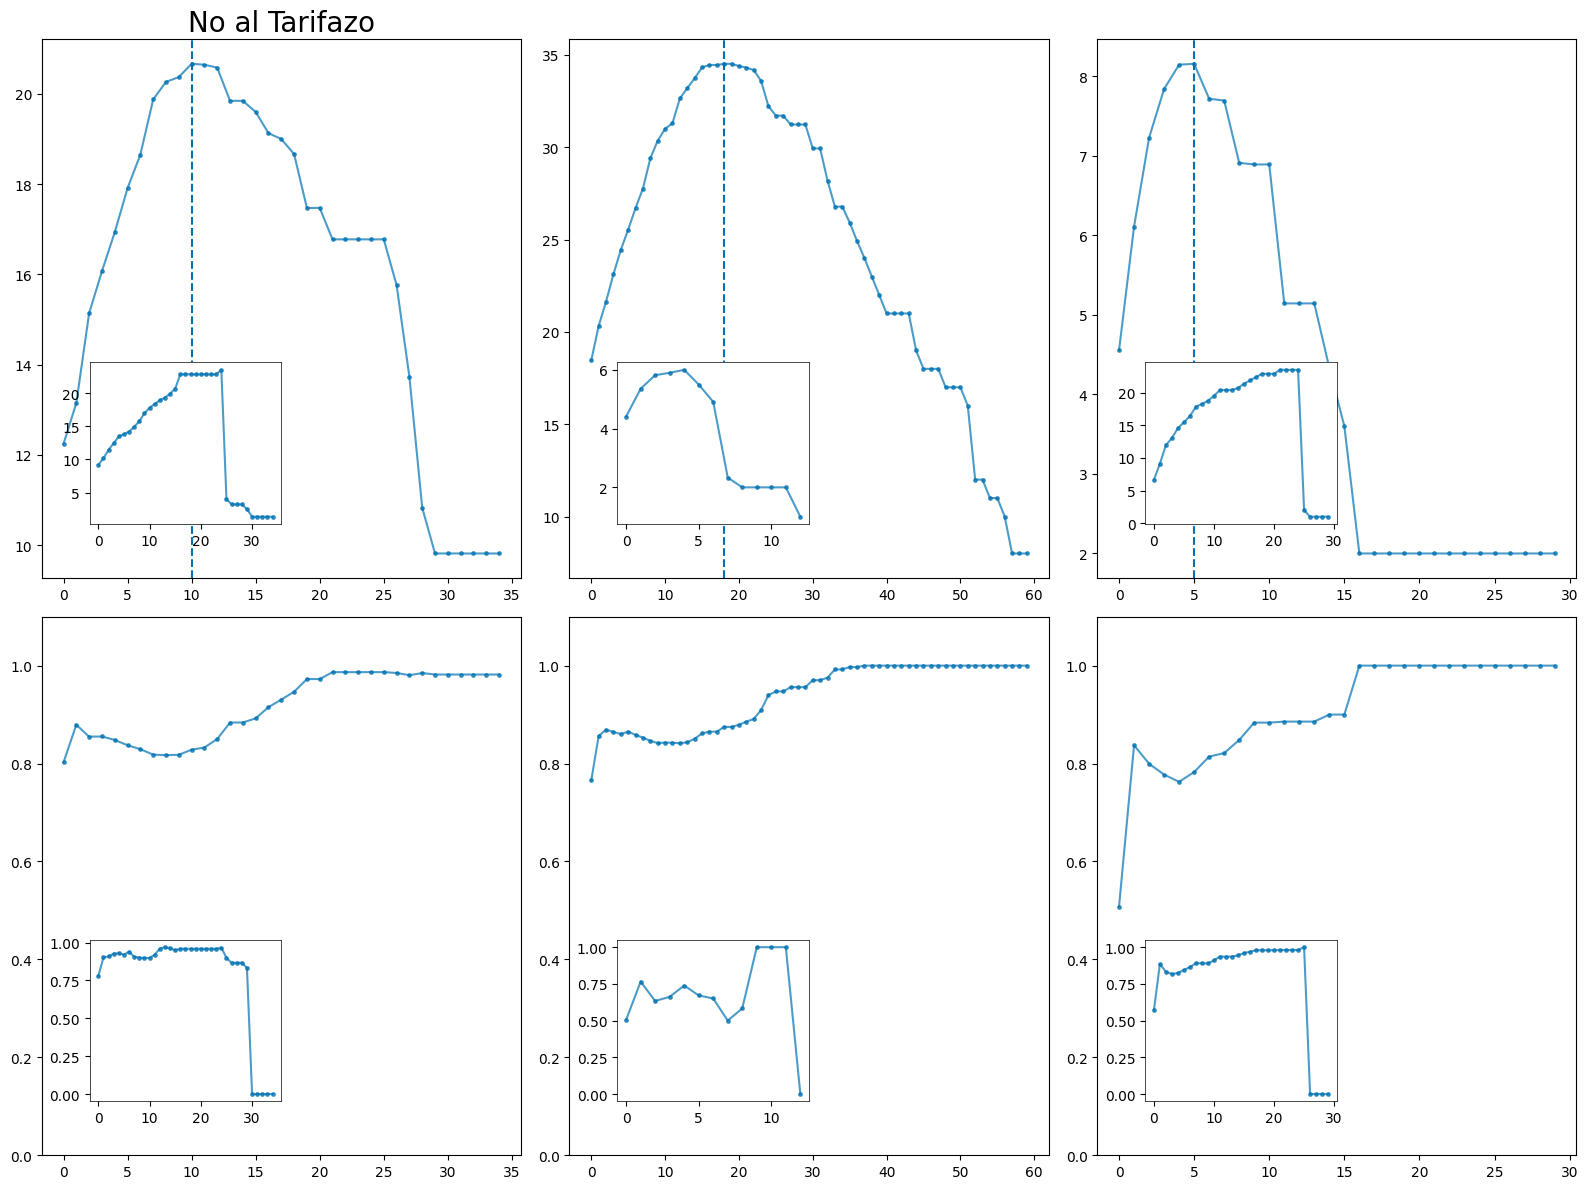

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat 
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,12)

xlim_nat = (0.1, 20)
xlim_9n = (0.1, 20)
xlim_ch = (0.1, 20)
xlim_wd = (0.1, 20)

xlim_otra_nat = (0.1, 10)
xlim_otra_9n = (0.1, 20) 
xlim_otra_ch = (0.1, 20)
xlim_otra_wd = (0.1, 20)


dot_size=4
marker = "" \
"x"
alpha=0.7

array_puntos_plfit = []

axs[0].set_title("No al Tarifazo", fontsize=20)
axs[0].plot(list(dict_hora_nat_f.keys())[0:limit_kt_nat], list(dict_hora_nat_f.values())[0:limit_kt_nat], alpha=alpha)
axs[0].scatter(list(dict_hora_nat_f.keys())[0:limit_kt_nat], list(dict_hora_nat_f.values())[0:limit_kt_nat], s=6, alpha=alpha)
axs[0].axvline(critical_kt_nat, ls="--")
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax0_inset)
ax0_inset.plot(list(dict_otra_hora_nat_f.keys())[0:limit_kt_nat], list(dict_otra_hora_nat_f.values())[0:limit_kt_nat], alpha=alpha)
ax0_inset.scatter(list(dict_otra_hora_nat_f.keys())[0:limit_kt_nat], list(dict_otra_hora_nat_f.values())[0:limit_kt_nat], s=6, alpha=alpha)



axs[1].plot(list(dict_hora_9n_f.keys())[0:limit_kt_9n], list(dict_hora_9n_f.values())[0:limit_kt_9n], alpha=alpha)
axs[1].scatter(list(dict_hora_9n_f.keys())[0:limit_kt_9n], list(dict_hora_9n_f.values())[0:limit_kt_9n], s=6, alpha=alpha)
axs[1].axvline(critical_kt_9n, ls="--")
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax1_inset)
ax1_inset.plot(list(dict_otra_hora_9n_f.keys())[0:limit_kt_9n], list(dict_otra_hora_9n_f.values())[0:limit_kt_9n], alpha=alpha)
ax1_inset.scatter(list(dict_otra_hora_9n_f.keys())[0:limit_kt_9n], list(dict_otra_hora_9n_f.values())[0:limit_kt_9n], s=6, alpha=alpha)


axs[2].plot(list(dict_hora_ch_f.keys())[0:limit_kt_ch], list(dict_hora_ch_f.values())[0:limit_kt_ch], alpha=alpha)
axs[2].scatter(list(dict_hora_ch_f.keys())[0:limit_kt_ch], list(dict_hora_ch_f.values())[0:limit_kt_ch], s=6, alpha=alpha)
axs[2].axvline(critical_kt_ch, ls="--")
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax2_inset)
ax2_inset.plot(list(dict_otra_hora_ch_f.keys())[0:limit_kt_ch], list(dict_otra_hora_ch_f.values())[0:limit_kt_ch], alpha=alpha)
ax2_inset.scatter(list(dict_otra_hora_ch_f.keys())[0:limit_kt_ch], list(dict_otra_hora_ch_f.values())[0:limit_kt_ch], s=6, alpha=alpha)

axs[3].plot(list(dict_thres_avg_clust_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_nat_h_f.values())[0:limit_kt_nat], alpha=alpha)
axs[3].scatter(list(dict_thres_avg_clust_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_nat_h_f.values())[0:limit_kt_nat], s=6, alpha=alpha)
axs[3].set_ylim(0,1.1)
ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax3_inset)
ax3_inset.plot(list(dict_thres_avg_clust_otra_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_otra_nat_h_f.values())[0:limit_kt_nat], alpha=alpha)
ax3_inset.scatter(list(dict_thres_avg_clust_otra_nat_h_f.keys())[0:limit_kt_nat], list(dict_thres_avg_clust_otra_nat_h_f.values())[0:limit_kt_nat], s=6, alpha=alpha)


axs[4].plot(list(dict_thres_avg_clust_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_9n_h_f.values())[0:limit_kt_9n], alpha=alpha)
axs[4].scatter(list(dict_thres_avg_clust_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_9n_h_f.values())[0:limit_kt_9n], s=6, alpha=alpha)
axs[4].set_ylim(0,1.1)
ax4_inset = axs[4].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax4_inset)
ax4_inset.plot(list(dict_thres_avg_clust_otra_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_otra_9n_h_f.values())[0:limit_kt_9n], alpha=alpha)
ax4_inset.scatter(list(dict_thres_avg_clust_otra_9n_h_f.keys())[0:limit_kt_9n], list(dict_thres_avg_clust_otra_9n_h_f.values())[0:limit_kt_9n], s=6, alpha=alpha)

axs[5].plot(list(dict_thres_avg_clust_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_ch_h_f.values())[0:limit_kt_ch], alpha=alpha)
axs[5].scatter(list(dict_thres_avg_clust_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_ch_h_f.values())[0:limit_kt_ch], s=6, alpha=alpha)
axs[5].set_ylim(0,1.1)
ax5_inset = axs[5].inset_axes([0.1, 0.1, 0.4, 0.3])
configure_inset(ax5_inset)
ax5_inset.plot(list(dict_thres_avg_clust_otra_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_otra_ch_h_f.values())[0:limit_kt_ch], alpha=alpha)
ax5_inset.scatter(list(dict_thres_avg_clust_otra_ch_h_f.keys())[0:limit_kt_ch], list(dict_thres_avg_clust_otra_ch_h_f.values())[0:limit_kt_ch], s=6, alpha=alpha)






plt.tight_layout()
#plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

## Disparity filter

In [ ]:
import numpy as np
def backbone_confidence(filename, filenameout):
	NODOSMAX = 100000
	NEDGESMAX = 1000000

	internalnet = np.zeros((NEDGESMAX, 2), dtype=int)
	weight = np.zeros(NEDGESMAX)
	strenght = np.zeros(NODOSMAX)
	ndegree = np.zeros(NODOSMAX, dtype=int)
	nodepresent = np.zeros(NODOSMAX, dtype=int)
	weightmin = 0.0

	#filename = '../Data/distancesbetweencities_Spain_ids.csv'  # input network
	#filenameout = '../Data/cities_Spain_stat.dat'  # output file

	for i in range(NODOSMAX):
		strenght[i] = 0.0
		ndegree[i] = 0

	for i in range(NEDGESMAX):
		weight[i] = 0.0

	weighttotal = 0.0
	NODOS = 0
	nlink = 0

	with open(filename, 'r') as f:
		for line in f:
			
			arr = line.split(',')
			i, j, d = arr[0], arr[1], float(int(arr[2]))
			i, j = int(i), int(j)
			if d == 0:
				print(f"cities {i} {j} have distance 0")
				d += 0.1
			#w = 1.0 / d**(1.0)
			w = d
			nlink += 1
			internalnet[nlink - 1, 0] = i
			internalnet[nlink - 1, 1] = j
			strenght[i] += w
			strenght[j] += w
			ndegree[i] += 1
			ndegree[j] += 1
			weight[nlink - 1] = w
			weighttotal += w
			NODOS = max(NODOS, i, j)

	with open(filenameout, 'w') as f:
		for n in range(10000):
			wconfidence = float(n) * 0.0001
			nodepresent.fill(0)

			weightbackbone = 0.0
			nedgesbackbone = 0
			weightnodeszerodegree = 0.0

			for i in range(nlink):
				if (ndegree[internalnet[i, 1]] > 1) and (ndegree[internalnet[i, 0]] > 1):
					if (weight[i] / strenght[internalnet[i, 0]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 0]] - 1)))) or \
					(weight[i] / strenght[internalnet[i, 1]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 1]] - 1)))):
						weightbackbone += weight[i]
						nedgesbackbone += 1
						nodepresent[internalnet[i, 0]] = 1
						nodepresent[internalnet[i, 1]] = 1
				elif (ndegree[internalnet[i, 1]] > 1) and (ndegree[internalnet[i, 0]] == 1):
					if (weight[i] / strenght[internalnet[i, 1]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 1]] - 1)))):
						weightbackbone += weight[i]
						nedgesbackbone += 1
						nodepresent[internalnet[i, 0]] = 1
						nodepresent[internalnet[i, 1]] = 1
				elif (ndegree[internalnet[i, 1]] == 1) and (ndegree[internalnet[i, 0]] > 1):
					if (weight[i] / strenght[internalnet[i, 0]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 0]] - 1)))):
						weightbackbone += weight[i]
						nedgesbackbone += 1
						nodepresent[internalnet[i, 0]] = 1
						nodepresent[internalnet[i, 1]] = 1
				else:
					weightnodeszerodegree += weight[i]

			nodosbackbone = 0
			strenghtbackbone = 0.0
			for i in range(NODOS):
				if nodepresent[i] == 1:
					nodosbackbone += 1
					strenghtbackbone += strenght[i] - strenght[i]

			f.write(f"{wconfidence:.6f} {weightbackbone / weighttotal:.4f} {nodosbackbone / NODOS:.4f} {nedgesbackbone / nlink:.4f}\n")

In [ ]:
import numpy as np
def backbone1(filename, filenameout, wconfidence):
	NODOSMAX = 100000
	NEDGESMAX = 1000000

	internalnet = np.zeros((NEDGESMAX, 2), dtype=int)
	weight = np.zeros(NEDGESMAX)
	strenght = np.zeros(NODOSMAX)
	ndegree = np.zeros(NODOSMAX, dtype=int)

	weightmin = 0.0
	#wconfidence = 0.9977  # this is 1-alfa

	#filename = '../Data/distancesbetweencities_Spain_ids.csv'  # input network
	#filenameout = '../Data/backbone_Spain_0.9977_nw.net'  # output backbone

	for i in range(NODOSMAX):
		strenght[i] = 0.0
		ndegree[i] = 0

	for i in range(NEDGESMAX):
		weight[i] = 0.0

	weighttotal = 0.0
	NODOS = 0
	nlink = 0

	with open(filename, 'r') as f:
		while True:
			line = f.readline()
			if not line:
				break
			arr = line.split(',')
			i, j, d = arr[0], arr[1], float(int(arr[2]))
			i, j = int(i), int(j)
			if d == 0:
				print(f"cities {i} {j} have distance 0")
				d += 0.1
			#w = 1.0 / d**(1.0)
			w = d
			nlink += 1
			internalnet[nlink - 1, 0] = i
			internalnet[nlink - 1, 1] = j
			strenght[i] += w
			strenght[j] += w
			ndegree[i] += 1
			ndegree[j] += 1
			weight[nlink - 1] = w
			weighttotal += w
			NODOS = max(NODOS, i, j)

	weightbackbone = 0.0

	with open(filenameout, 'w') as f:
		for i in range(nlink):
			if internalnet[i,1] == 14652 and internalnet[i, 0] == 2812:
				print(weight[i])
			if (ndegree[internalnet[i, 1]] > 1) and (ndegree[internalnet[i, 0]] > 1):
				if (weight[i] / strenght[internalnet[i, 0]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 0]] - 1)))) or \
				(weight[i] / strenght[internalnet[i, 1]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 1]] - 1)))):
					if weight[i] > weightmin:
						f.write(f"{internalnet[i, 0]} {internalnet[i, 1]} {weight[i]}\n")
						weightbackbone += weight[i]
			elif (ndegree[internalnet[i, 1]] > 1) and (ndegree[internalnet[i, 0]] == 1):
				if weight[i] / strenght[internalnet[i, 1]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 1]] - 1))):
					if weight[i] > weightmin:
						f.write(f"{internalnet[i, 0]} {internalnet[i, 1]} {weight[i]}\n")
						weightbackbone += weight[i]
			elif (ndegree[internalnet[i, 1]] == 1) and (ndegree[internalnet[i, 0]] > 1):
				if weight[i] / strenght[internalnet[i, 0]] > (1 - (1 - wconfidence)**(1 / (ndegree[internalnet[i, 0]] - 1))):
					if weight[i] > weightmin:
						f.write(f"{internalnet[i, 0]} {internalnet[i, 1]} 0\n")
						weightbackbone += weight[i]

	print('fraction of weight in backbone=', weightbackbone / weighttotal, filenameout)

In [ ]:
def convertir_file1(hora):
	G = nx.read_gexf(f"graphs/nodes_hashtag/nat/1/{hora}.gexf")
		
	with open(f"disparity_filter/puntos/{hora}.csv", "w") as f:
		arr_edges = ""
		for orig, dst, we in G.edges(data=True):
			if "weight" not in G[orig][dst].keys():
				print(orig, dst)
			peso = int(G[orig][dst]["weight"])
			arr_edges = arr_edges + f"{orig},{dst},{peso} \n"
		f.write(arr_edges)
	

  0%|          | 0/8 [00:00<?, ?it/s]

fraction of weight in backbone= 0.925748502994012 disparity_filter/puntos/429552_conf05.csv


100%|██████████| 7/7 [00:00<00:00, 3023.08it/s]


Calculating best minimal value for power law fit


 12%|█▎        | 1/8 [00:00<00:01,  5.32it/s]

...

 88%|████████▊ | 7/8 [00:03<00:00,  2.30it/s]

fraction of weight in backbone= 0.9630956646363311 disparity_filter/puntos/429636_conf05.csv


100%|██████████| 7/7 [00:00<00:00, 983.62it/s]


Calculating best minimal value for power law fit


100%|██████████| 8/8 [00:04<00:00,  1.76it/s]


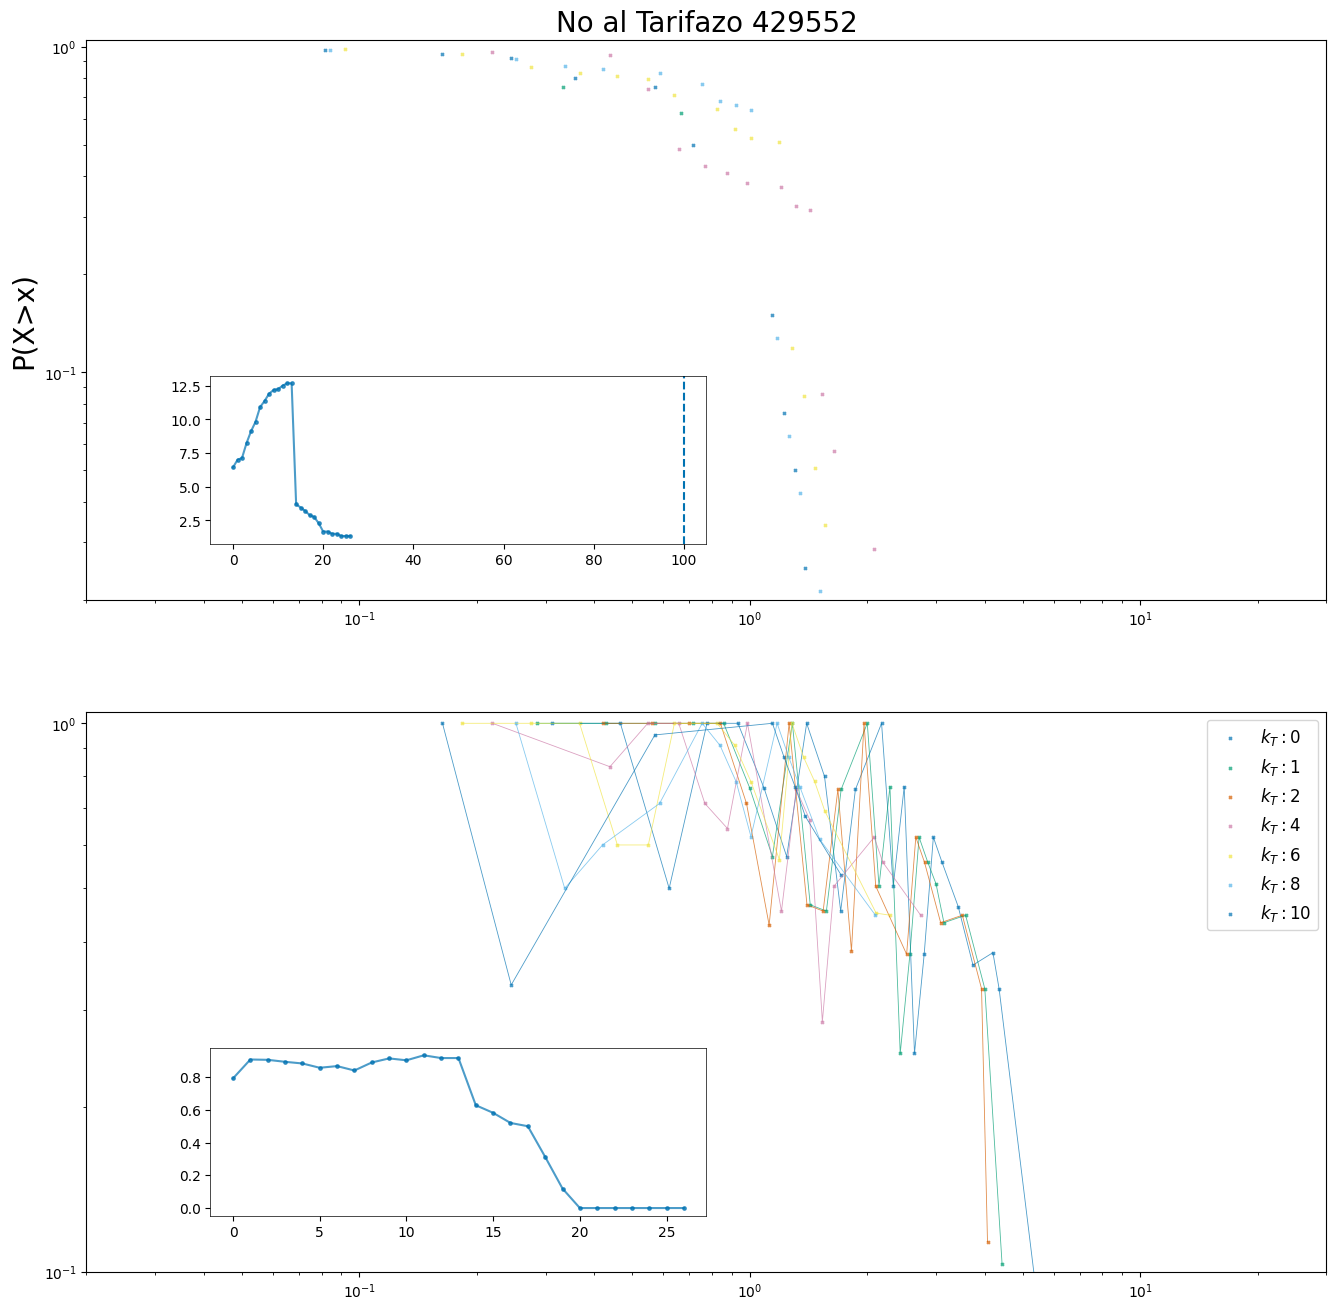

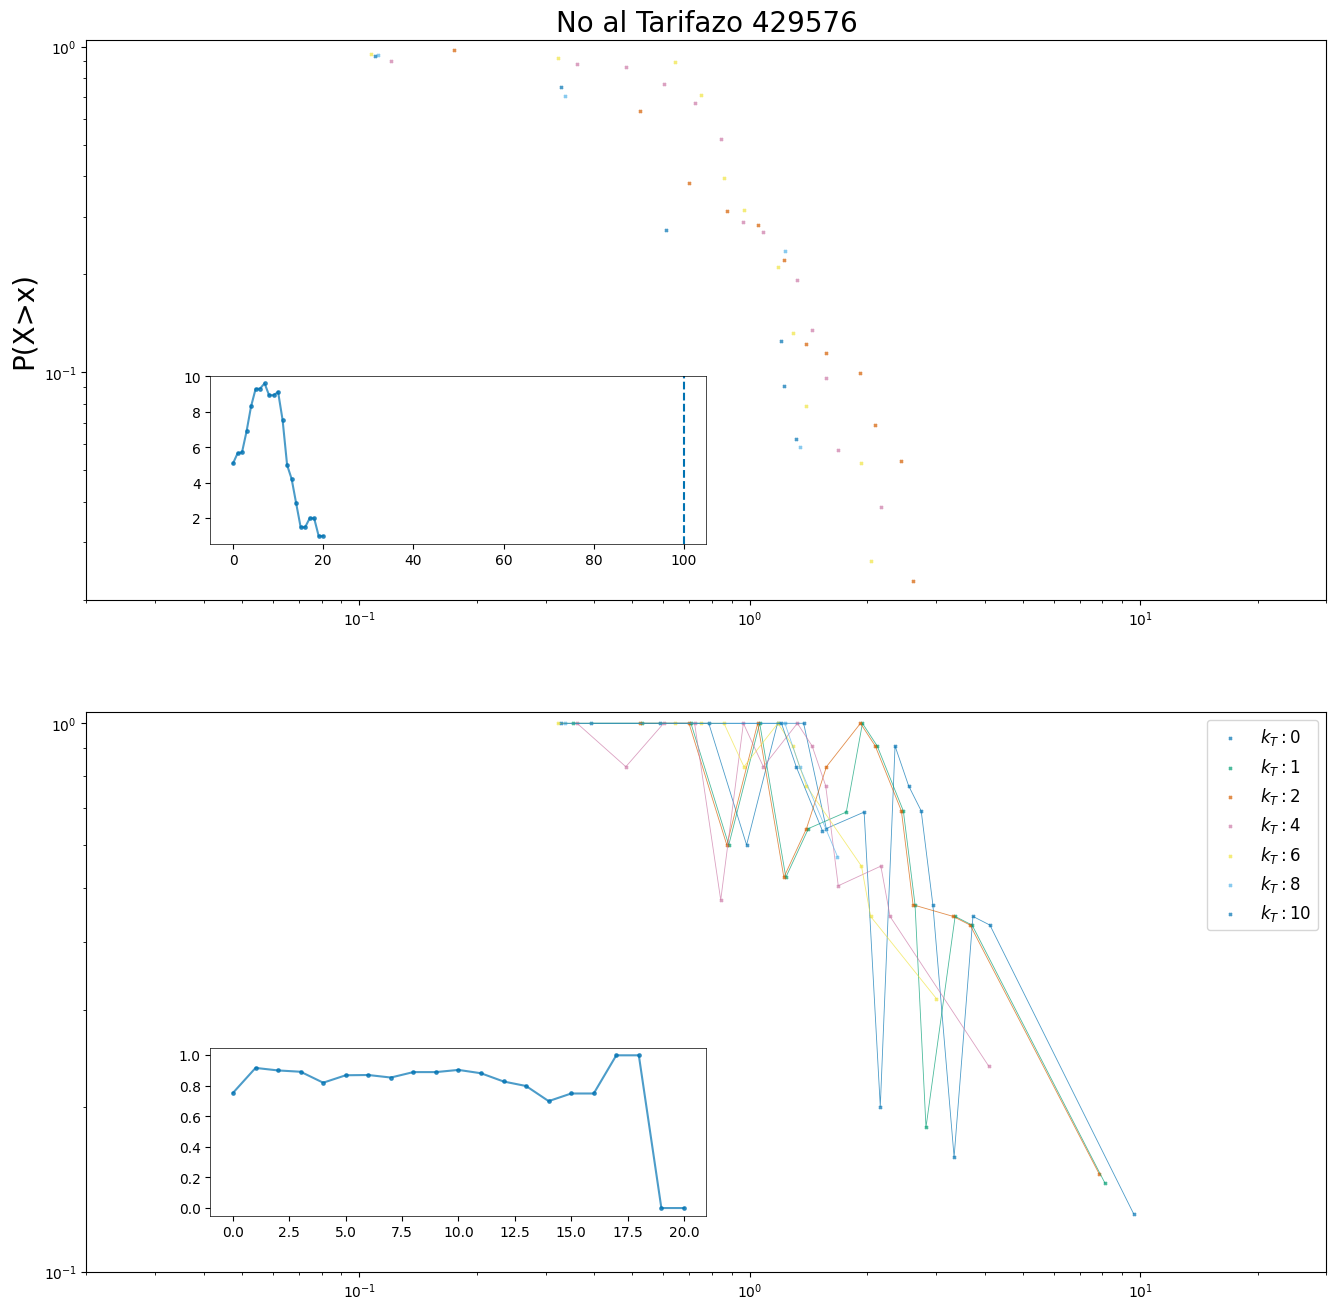

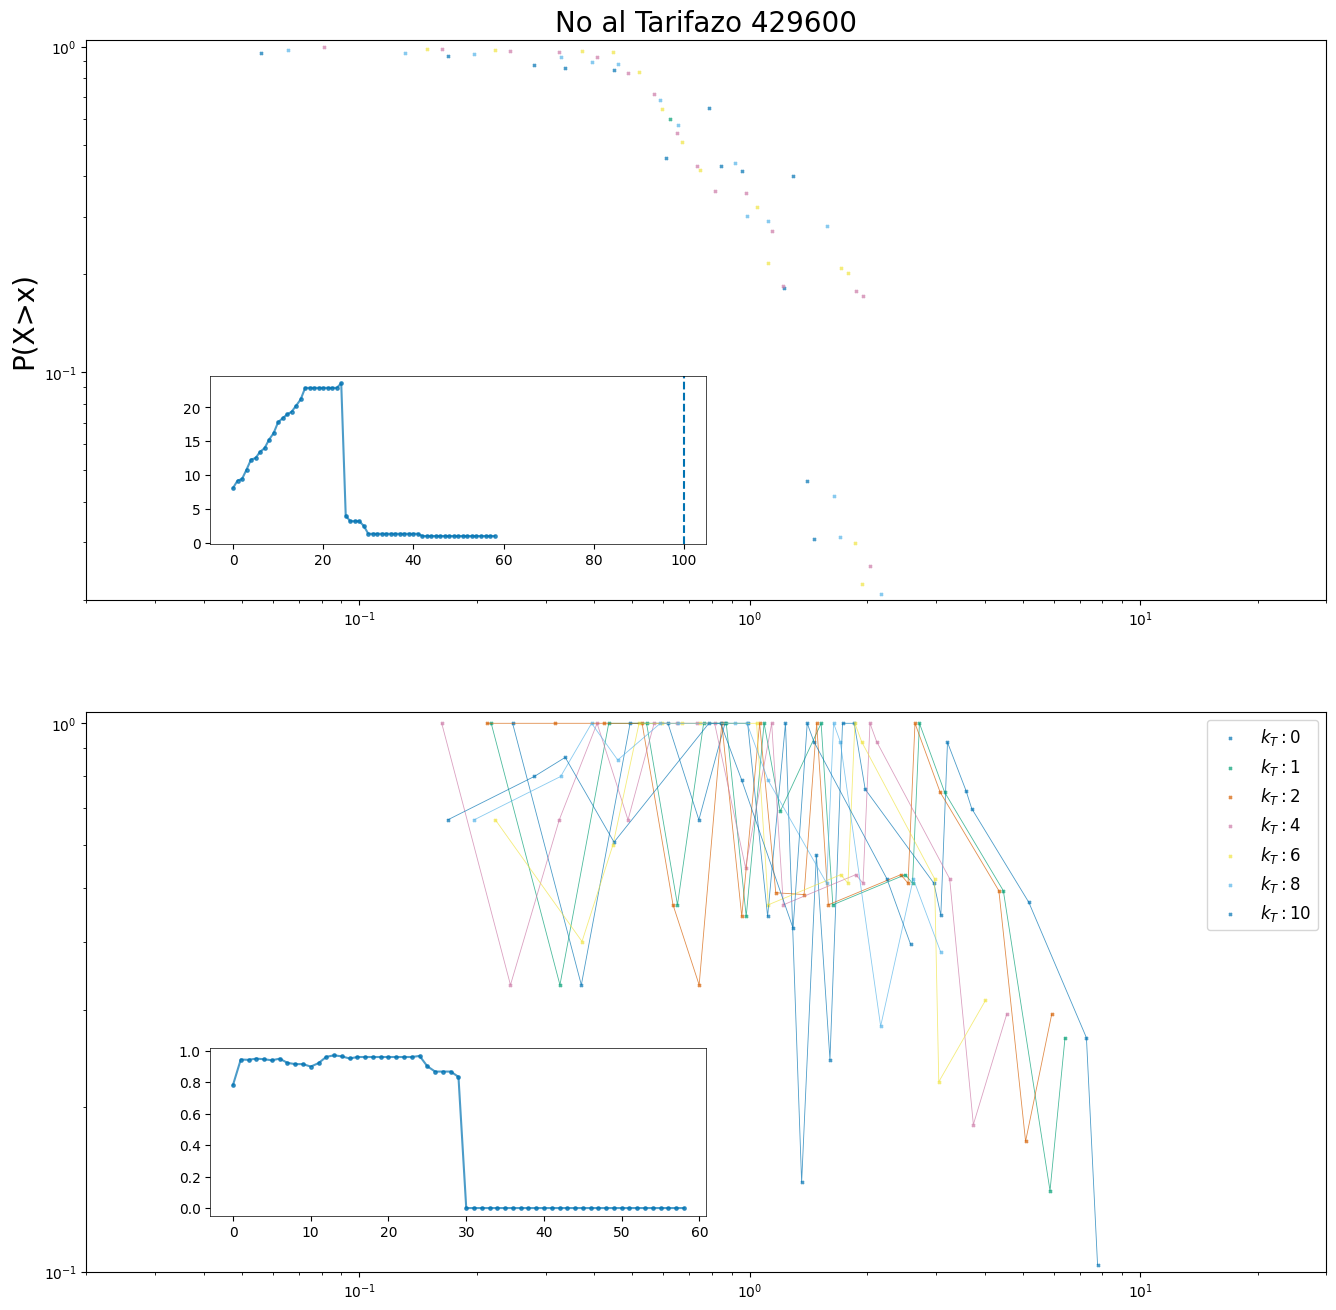

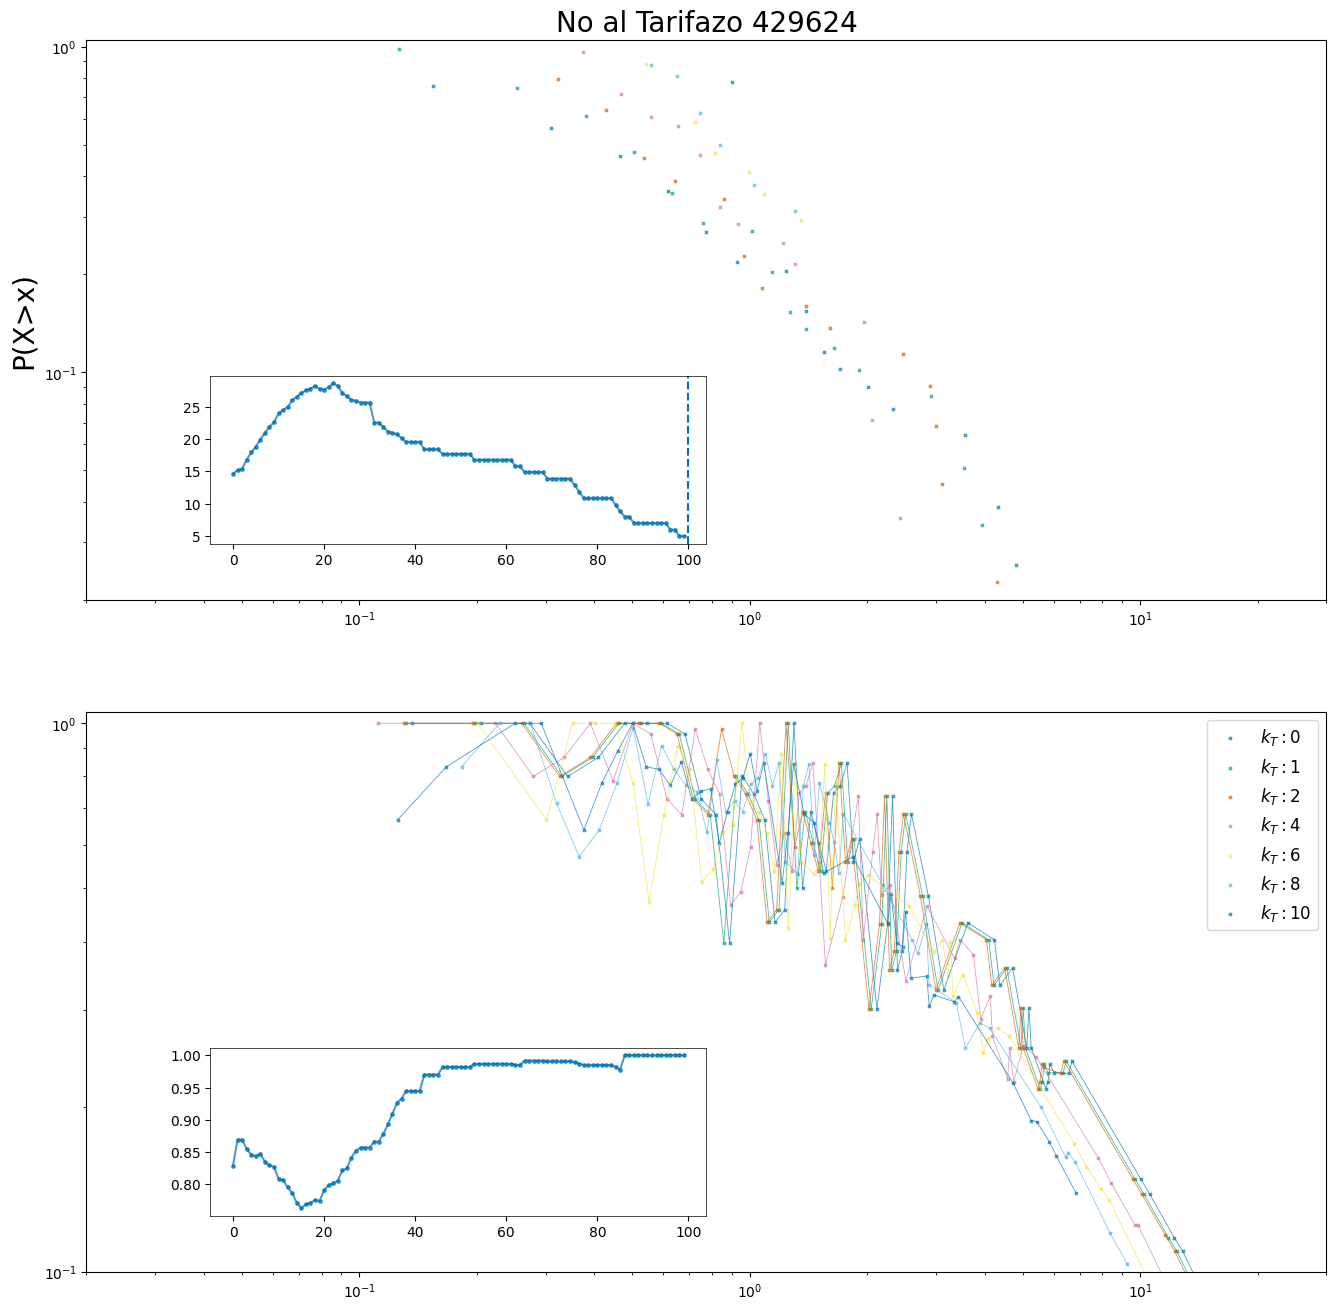

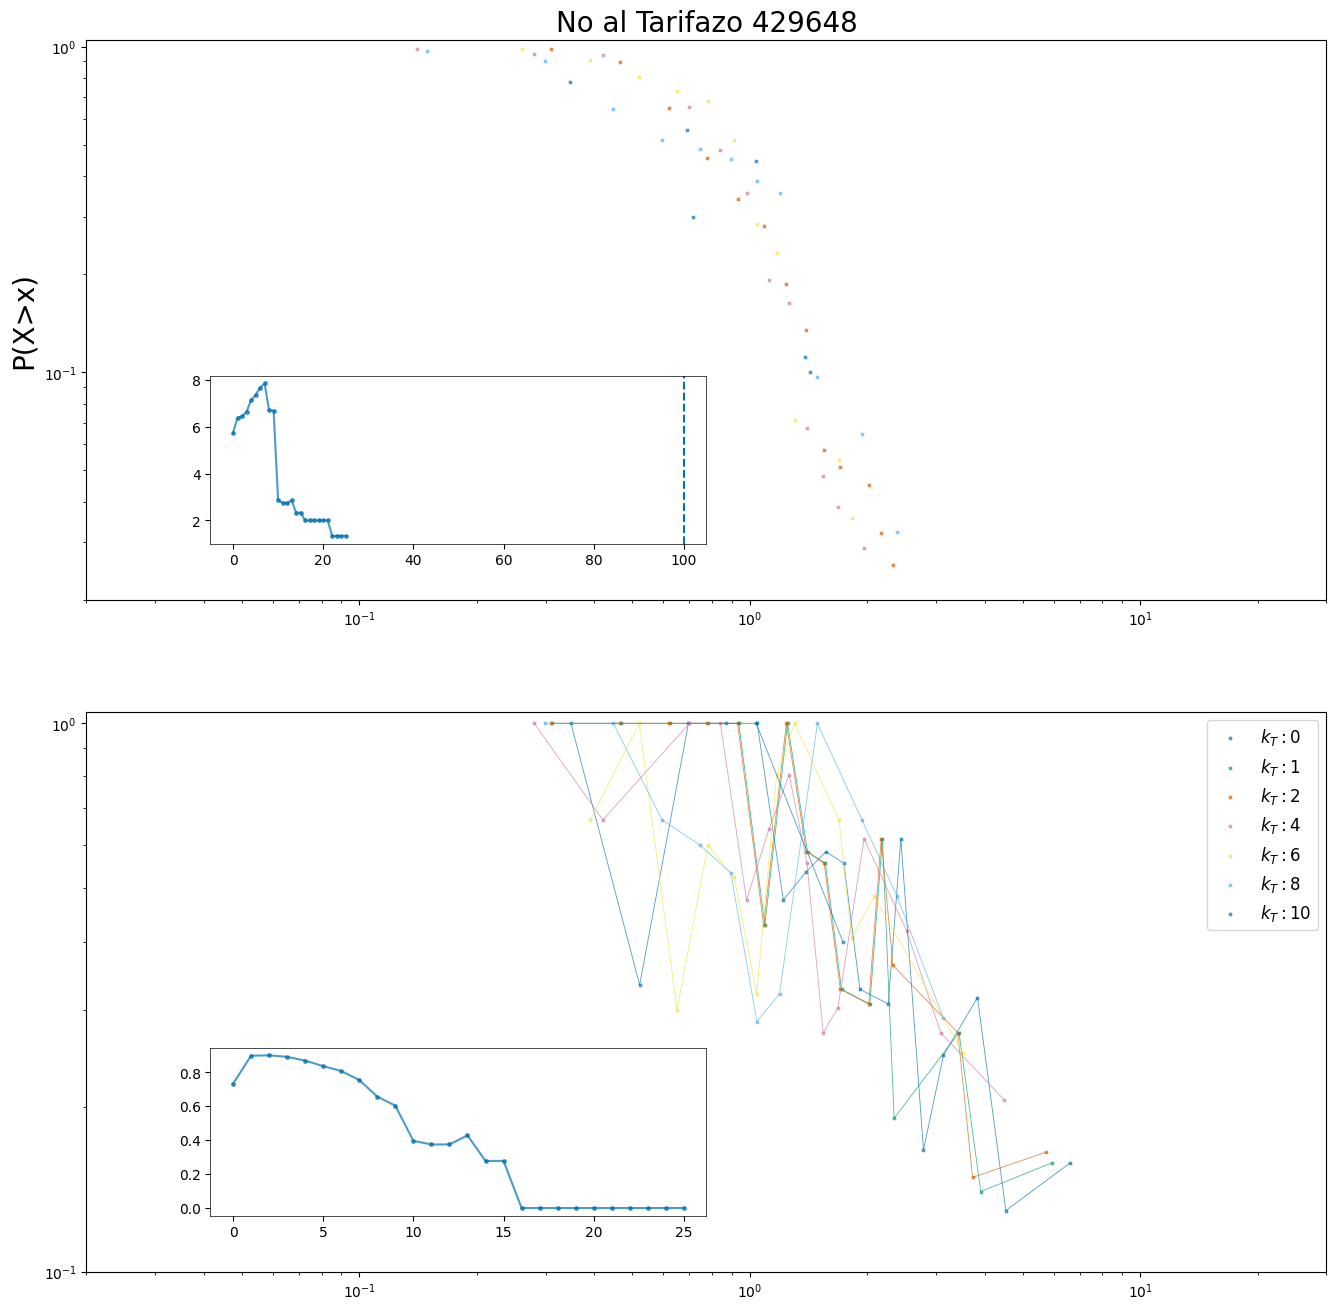

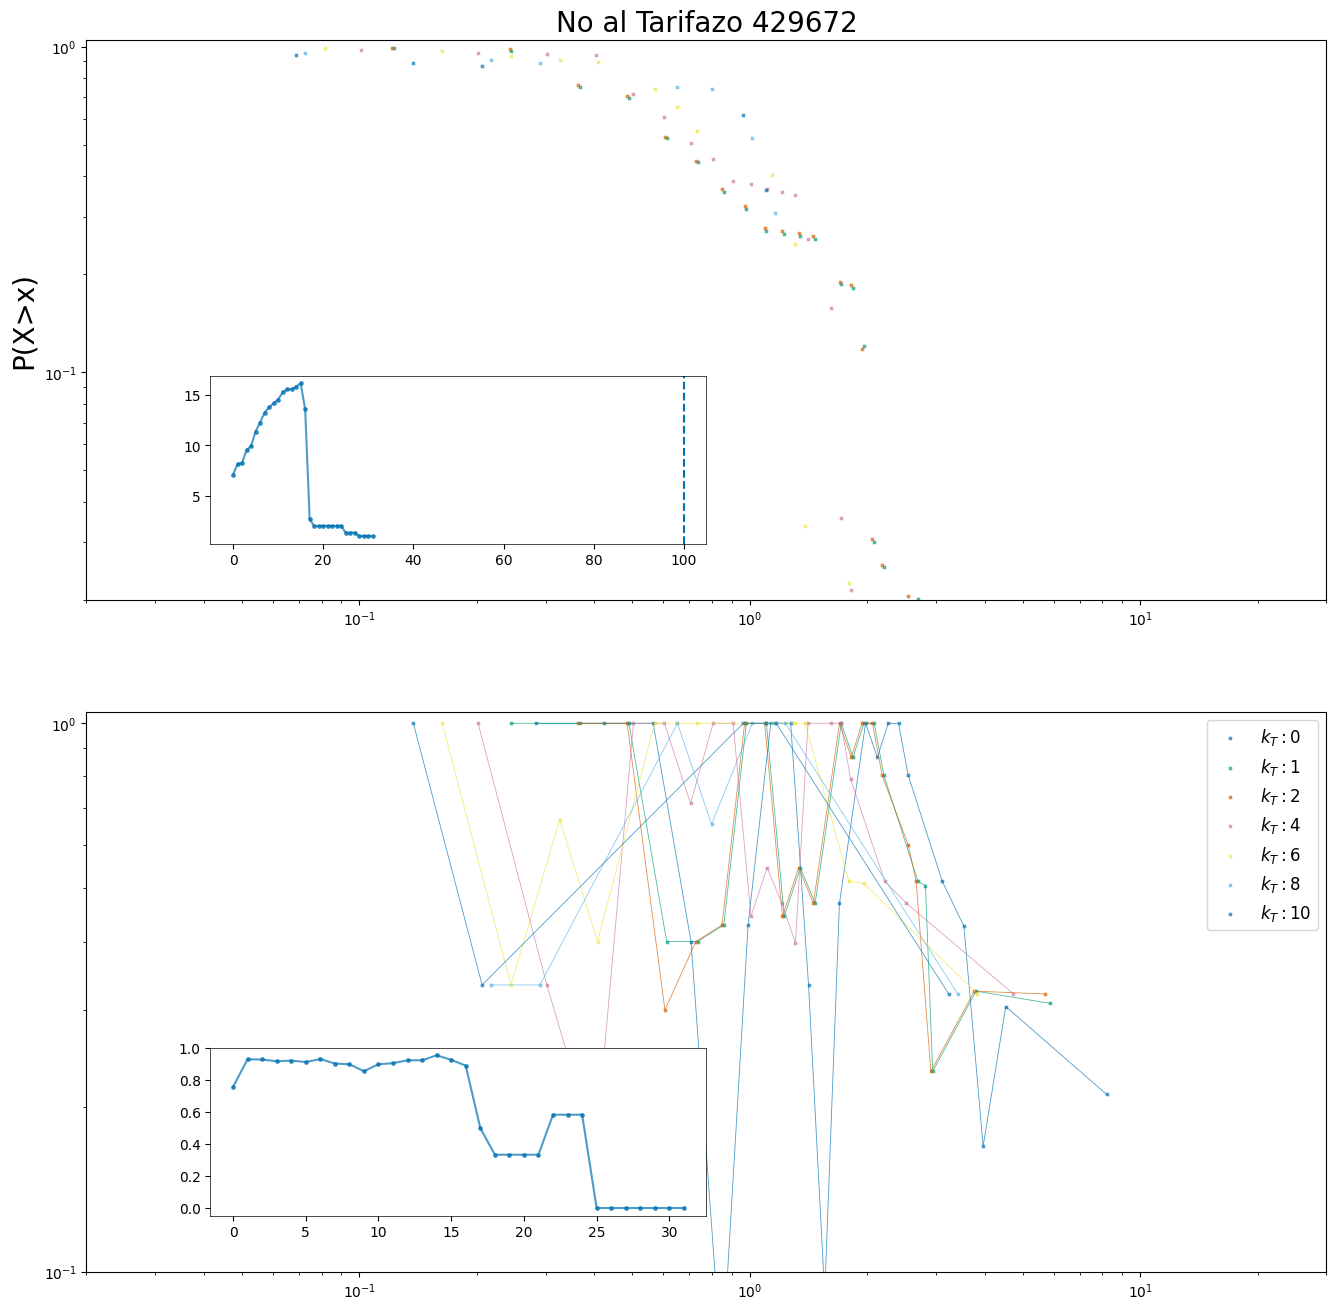

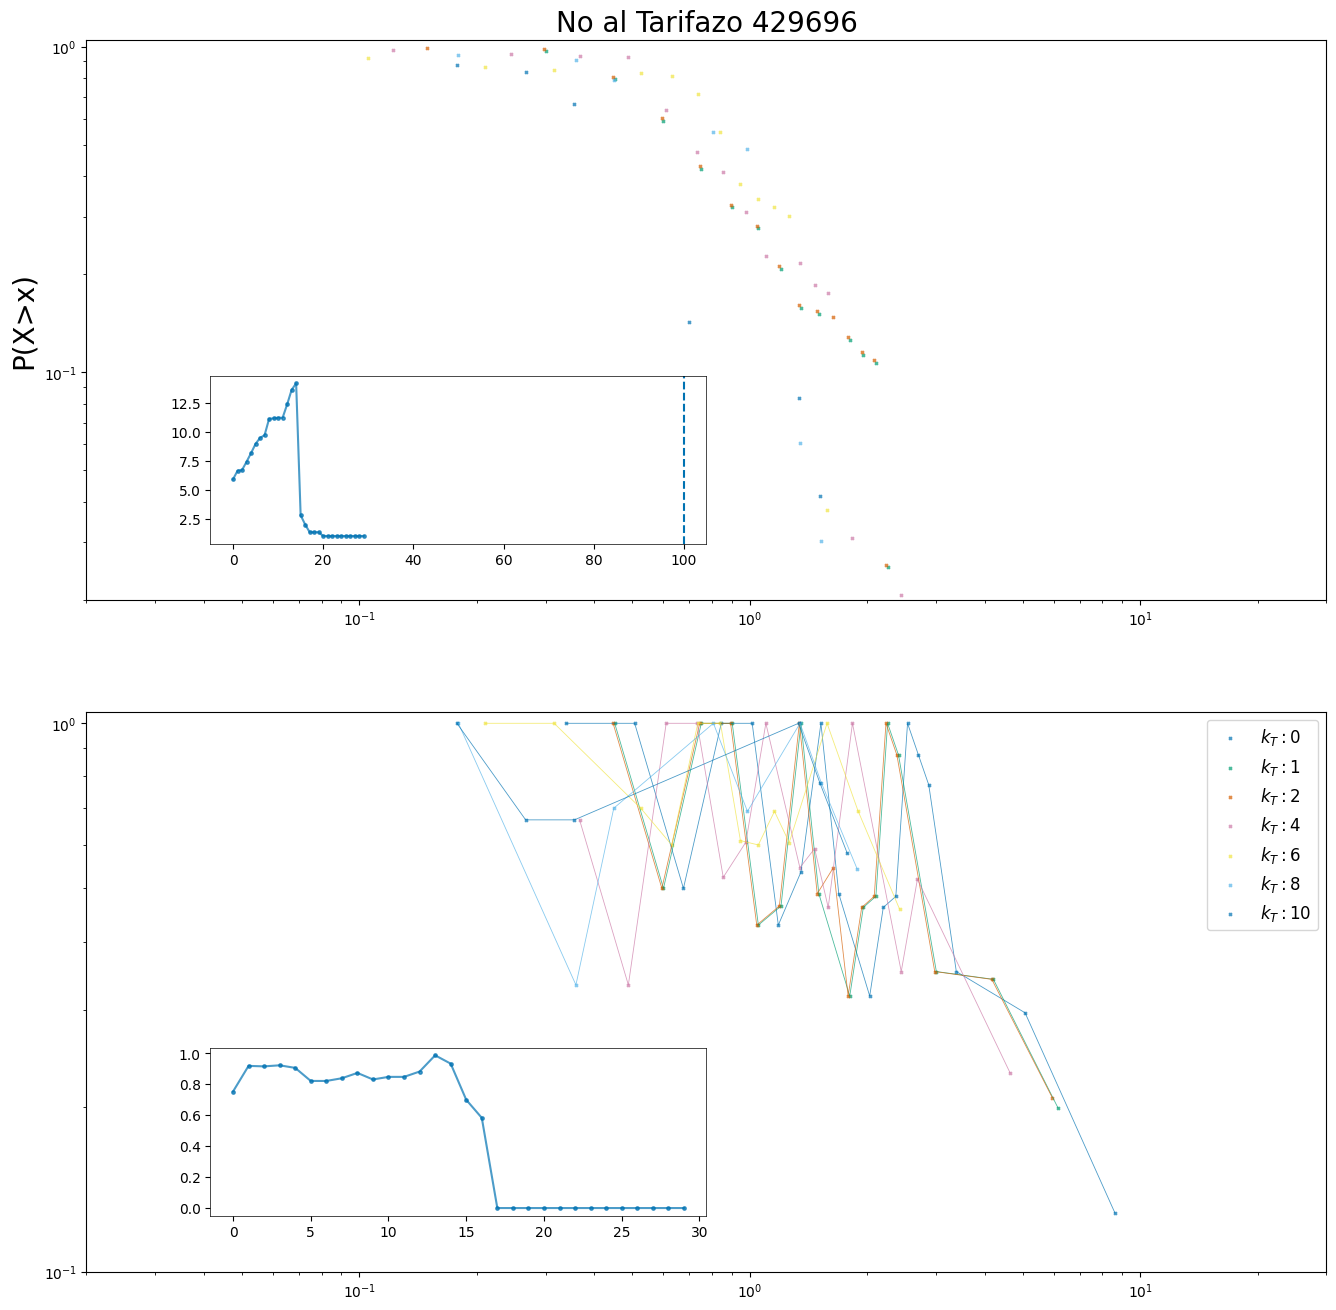

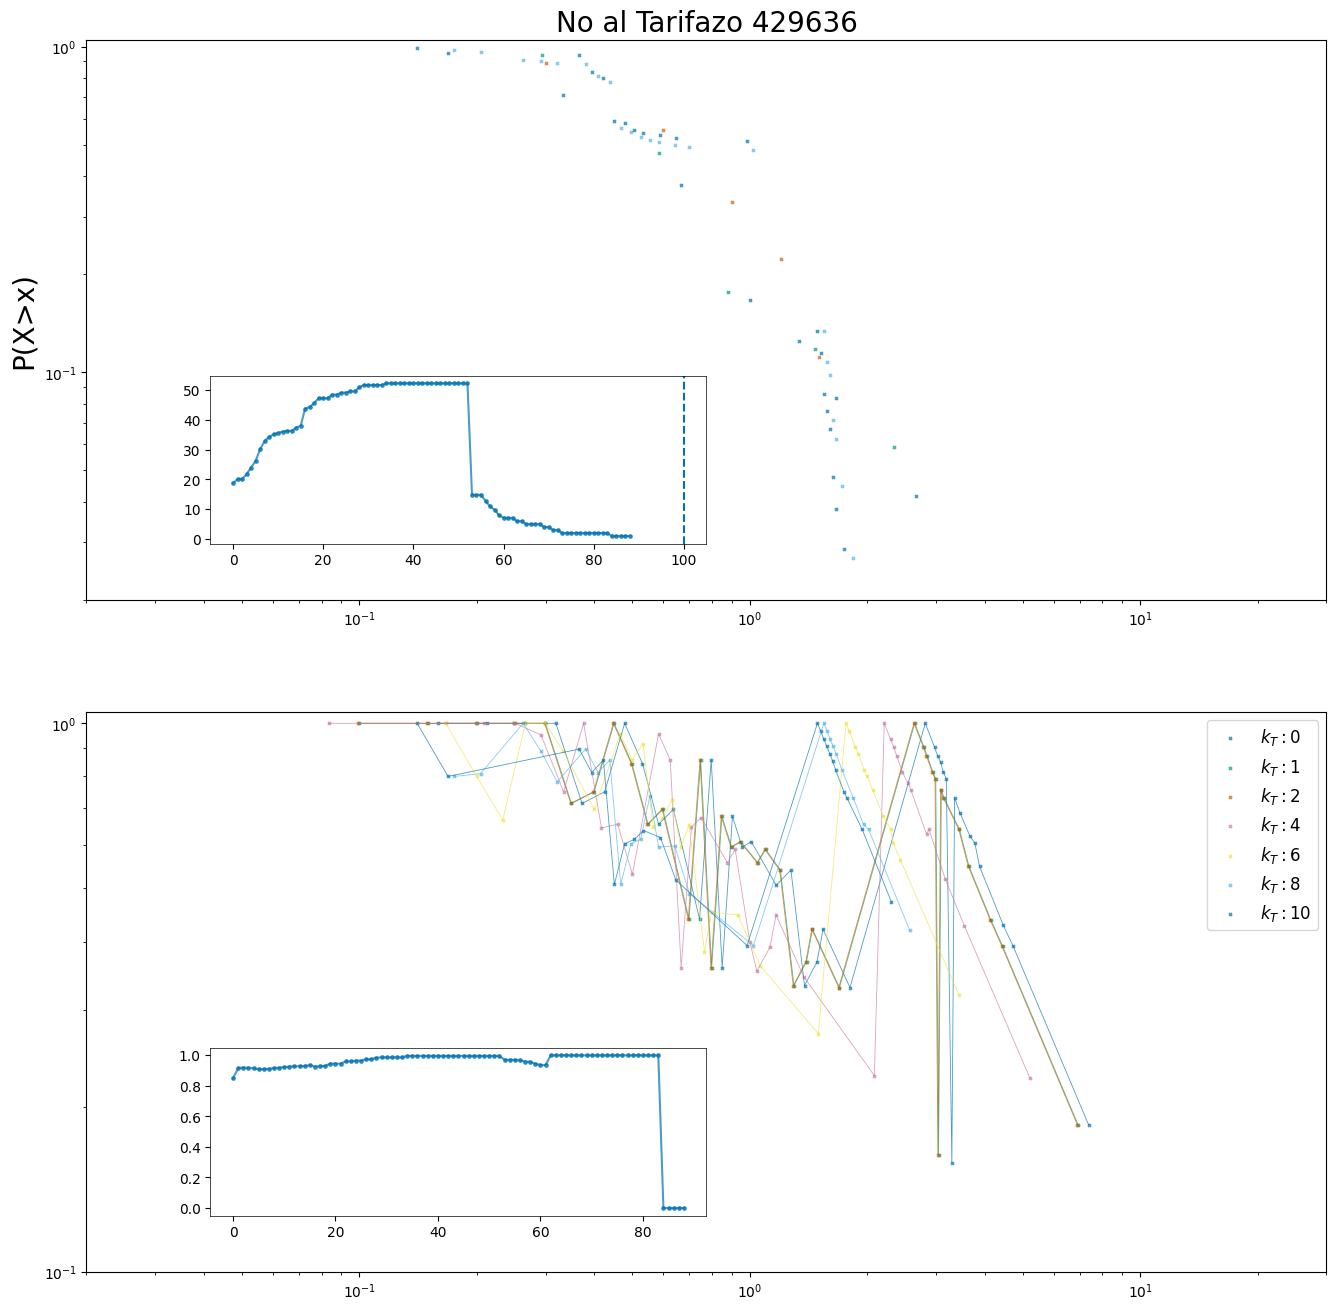

In [157]:
arr_kt_plot_nat_f = [0,1,2,4,6,8,10]
horas = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]
#horas = ["429624"]
for hora in tqdm(horas):
	convertir_file1(hora)
	filename_input = f"disparity_filter/puntos/{hora}.csv"
	filename_output = f"disparity_filter/puntos/{hora}_conf"
	#backbone_confidence(filename_input, filename_output + '.csv')
	backbone1(filename_input, filename_output + '05.csv', 0.5)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_conf05.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}.gexf")


	dict_hora_nat_f = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution1(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, norm=True)

	dict_thres_avg_clust_nat_h_f, dict_norm_int_deg_nat_h_f = calc_self_sim1(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")

	plt.style.use('seaborn-v0_8-colorblind')    

	fig, axs = plt.subplots(2, 1)
	axs = axs.flat
	for ax in axs:  
		ax.set_facecolor("white")
	fig.set_size_inches(16,16)

	plot_pdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, title=f"No al Tarifazo {hora}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))
	ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax0_inset, dict_hora_nat_f, 100, axvline=100)


	plot_clust_ss(axs[1], arr_kt_plot_nat_f, dict_norm_int_deg_nat_h_f, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)
	ax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
	plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_h_f, 100, dot_size=6)



In [ ]:
def calc_degree_distribution1(hour, manifestacion, graphs_folder="graphs/", mode="h", measures_folder="measures/", G=None, arr_kt=[0], exp=False, read=True, write=True, norm=False, thresh_filt=5):
	
	if mode == "h":
		path_graph = "nodes_hashtag/"
	elif mode == "u":
		path_graph = "nodes_user/"
	elif mode == "b":
		path_graph = "nodes_bipartite/"
	elif mode == "f":
		path_graph = "nodes_filtered/" + str(thresh_filt) + '/'
	elif mode == "d":
		path_graph = "nodes_disparity/"
	
	# Se carga el grafo inicial
	G = nx.read_gexf(graphs_folder + path_graph + manifestacion + hour + '.gexf')
		
	arr_points = []
	dict_points = {}
	measures_path = measures_folder + manifestacion + hour + '_' + mode + '_degs_kt.json'
	if read:
		# En los archivos se guardan los grados de los nodos de cada grafo dependiente de kt en bruto, sin sufrir procesos de normalización
		if os.path.exists(measures_path):
			try:
				with open(measures_path, 'r') as f:
					dict_points = json.load(f)
				dict_points = convert_keys_to_float(dict_points, tipo="int")
			except json.JSONDecodeError:
				pass
	
	# Si no recibe un arr_kt como parametro, se interpreta que es la red original
	for kt in tqdm(arr_kt):
		if not kt in dict_points.keys():
			F = thresh_normalization(G, kt)
			if F != -1:
				points_kt = np.sort(np.array(list(dict(F.degree()).values())).astype(float))
				dict_points[kt] = list(points_kt)
	
		else:
			points_kt = dict_points[kt]
		if norm:
			points_kt = np.array(points_kt) / np.mean(points_kt)
		arr_points.append(points_kt)
	# El exponente solo se va a calcular cuando se reciba un valor de kt
	plfit = None
	if exp:
		# Para calcular el exponente no hay que normalizar
		plfit = get_exp([dict_points[arr_kt[0]]])

	# Puntos de la PDF
	arr_deg_prob = []
	for points in arr_points:
		degrees, counts = np.unique(points, return_counts=True)
		probs = counts / len(points)
		arr_deg_prob.append((degrees, probs))
	# Puntos de la CDF
	arr_deg_cum = []
	for deg_prob in arr_deg_prob:
		cum_freq = np.cumsum(deg_prob[1])
		cdf = cum_freq/cum_freq[-1]
		arr_deg_cum.append((deg_prob[0], cdf))
		
	# Puntos de la CCDF
	arr_deg_comp_cum = []
	for deg_cum in arr_deg_cum:
		ccdf = 1 - deg_cum[1]
		arr_deg_comp_cum.append((deg_cum[0], ccdf))
		
	if write:
		with open(measures_path, "w") as f:
			json.dump(dict_points, f, indent=2)
	return plfit, arr_deg_prob, arr_deg_comp_cum



In [ ]:

def calc_self_sim1(hora, MAX_UMBRAL, manifestacion, mode='h', graphs_folder="graphs/", measures_folder="measures/", thresh_filter=5):

	if mode == "h":
		path_graph = "nodes_hashtag/"
	elif mode == "u":
		path_graph = "nodes_user/"
	elif mode == "b":
		path_graph = "nodes_bipartite/"
	elif mode == "f":
		path_graph = "nodes_filtered/" + str(thresh_filter) + '/'
	elif mode == "d":
		path_graph = "nodes_disparity/"
	G = nx.read_gexf(graphs_folder + path_graph  + manifestacion + hora + ".gexf")
	path_measures_hour = measures_folder + manifestacion
	if not os.path.exists(path_measures_hour):
		os.makedirs(path_measures_hour)
	return calc_clust(G, MAX_UMBRAL, path_measures_hour + hora, mode=mode, read=False, write=True)

 32%|███▎      | 65/200 [00:00<00:00, 6919.54it/s]


100%|██████████| 7/7 [00:00<00:00, 41469.11it/s]


Calculating best minimal value for power law fit


 32%|███▎      | 65/200 [00:00<00:00, 896.26it/s]


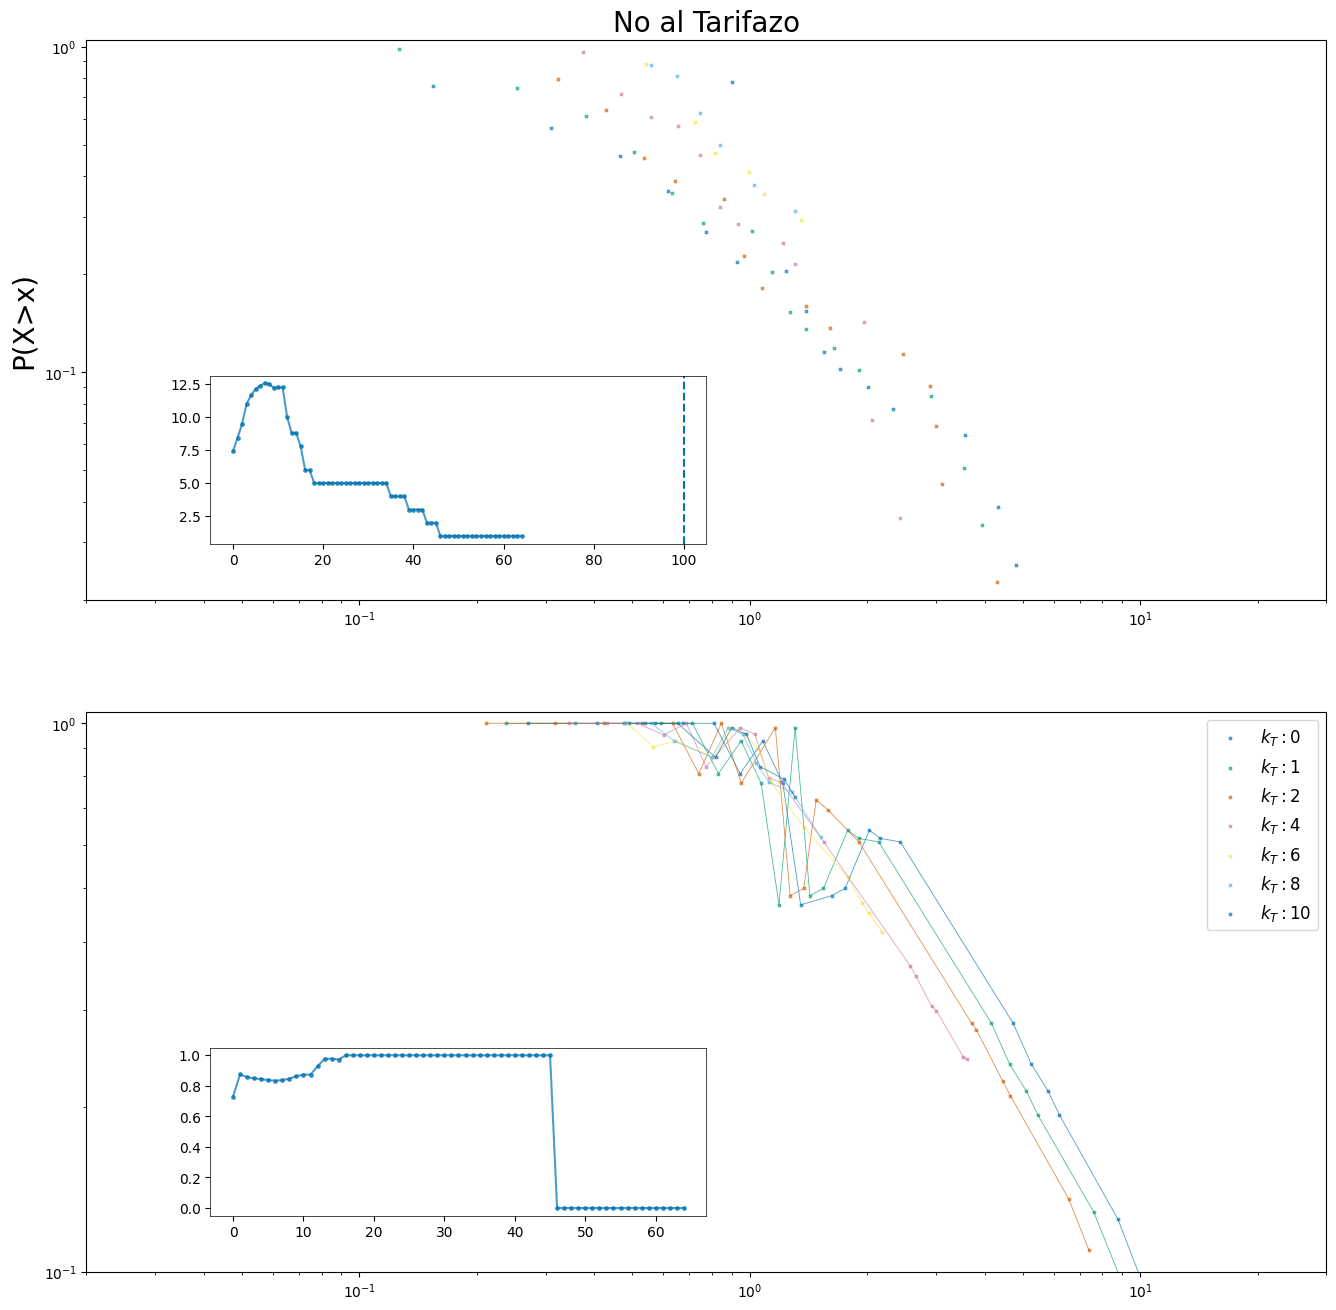

#  Gráfica CCDFs pre y post filtrado

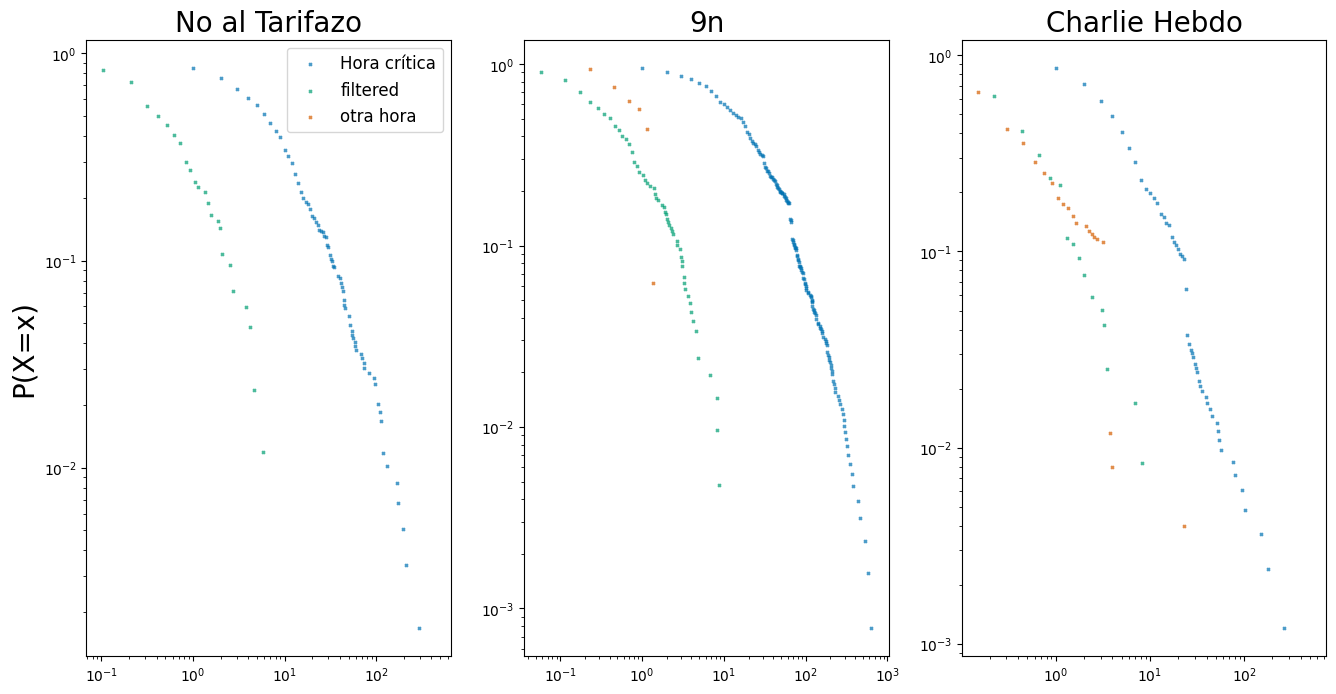

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(1, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,8)



dot_size=4
marker = "" \
"x"
alpha=0.7

array_puntos_plfit = []
axs[0].set_title("No al Tarifazo", fontsize=20)
for index, points in enumerate(arr_ccdf_points_nat[:1]):
	axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="Hora crítica")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
#axs[0].set_ylim(0.0002, 1.05)
#axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
axs[0].set_ylabel("P(X=x)", fontsize=20)

for index, points in enumerate(arr_ccdf_points_9n[:1]):
	axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="Hora crítica")
axs[1].set_xscale('log')
axs[1].set_yscale('log')
#axs[1].set_ylim(0.0002, 1.05)
#axs[1].set_xlim(xlim_9n[0], xlim_9n[1])
axs[1].set_title("9n", fontsize=20)

for index, points in enumerate(arr_ccdf_points_ch[:1]):
	axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="Hora crítica")
axs[2].set_xscale('log')
axs[2].set_yscale('log')
#axs[2].set_ylim(0.0002, 1.05)
#axs[2].set_xlim(xlim_ch[0], xlim_ch[1])
axs[2].set_title("Charlie Hebdo", fontsize=20)

for index, points in enumerate(arr_ccdf_points_nat_f[:1]):
	axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="filtered")

for index, points in enumerate(arr_ccdf_points_9n_f[:1]):
	axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="filtered")

for index, points in enumerate(arr_ccdf_points_ch_f[:1]):
	axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="filtered")

for index, points in enumerate(arr_ccdf_points_otra_nat_f[:1]):
	axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="otra hora")

for index, points in enumerate(arr_ccdf_points_otra_9n_f[:1]):
	axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="filtered")

for index, points in enumerate(arr_ccdf_points_otra_ch_f[:1]):
	axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="filtered")

axs[0].legend(prop={'size': 12})
plt.show()


# Grafica SS y CCDF (+ avg clust y avg deg in inset) muchas horas

In [ ]:
def horas_filtradas(horas_mov, manifestacion, hour_window, graphs_folder, filtered=False, umbral=None):
	horas_filt = []
	for hora in horas_mov:
		if filtered:
			write_filtered_graph(manifestacion, hora, umbral, graphs_folder, hour_window)

			G = nx.read_gexf(graphs_folder + f"nodes_filtered/{umbral}/{manifestacion}/{hour_window}/{hora}.gexf")
		else:
			# Si no se filtran los nodos, se leen los archivos sin el sufijo 'filtered'
			G = nx.read_gexf(graphs_folder + f"nodes_hashtag/{manifestacion}/{hour_window}/{hora}.gexf")
		if len(G.nodes) > 50:
			horas_filt.append(hora)
	return horas_filt

In [ ]:
def proc_data_ccdf(hora, manifestacion, hour_window, graphs_folder, measures_folder, arr_kt=None, umbral=None, norm=False):
	plfit, arr_pdf_points, arr_ccdf_points= calc_degree_distribution(hora, f"{manifestacion}/{hour_window}/", mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt, thresh_filt=umbral, norm=True)
	return plfit, arr_pdf_points, arr_ccdf_points

In [ ]:
def calc_avg_deg_kt(graphs_folder, hora, manifestacion, hour_window, umbral):
	dict_hora = {}
	G_nat = nx.read_gexf(graphs_folder + f"nodes_filtered/{umbral}/{manifestacion}/{hour_window}/{hora}.gexf")
	for threshold in tqdm(range(MAX_UMBRAL)):
		threshold = float(threshold)
		if not threshold in dict_hora.keys():
			# Se crea el subgrafo basandose en el threshold seleccionado
			F = thresh_normalization(G_nat,  threshold)
			if F == -1:
				# Caso de grafo vacío o grafo inconexo
				break 
			dict_hora[threshold] = calc_avg_degree(F)
	return dict_hora

In [ ]:
def plot(hora, manifestacion, hour_window, arr_kt_plot, umbral, axs_row):
	write_filtered_graph(manifestacion, hora, umbral, graphs_folder, hour_window)

	_, _, arr_ccdf_points = proc_data_ccdf(hora, manifestacion, hour_window, graphs_folder, measures_folder, arr_kt=arr_kt_plot, umbral=umbral, norm=True)
	dict_hora = calc_avg_deg_kt(graphs_folder, hora, manifestacion, hour_window, umbral)
	dict_thres_avg_clust, dict_norm_int_deg = calc_self_sim(hora, MAX_UMBRAL, f"{manifestacion}/{hour_window}/")
	limit_kt = 40
	
	for index, points in enumerate(arr_ccdf_points):
		axs_row[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="$k_t : $" + str(arr_kt_plot[index]))
	axs_row[0].set_xscale('log')
	axs_row[0].set_yscale('log')
	axs_row[0].set_ylim(0.02, 1.05)
	#axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
	axs_row[0].set_title(f"{manifestacion}-{hora}", fontsize=20)
	axs_row[0].set_ylabel("P(X>x)", fontsize=20)


	ax0_inset = axs_row[0].inset_axes([0.1, 0.1, 0.4, 0.3])
	configure_inset(ax0_inset)
	ax0_inset.plot(list(dict_hora.keys())[0:limit_kt], list(dict_hora.values())[0:limit_kt], alpha=alpha)
	ax0_inset.scatter(list(dict_hora.keys())[0:limit_kt], list(dict_hora.values())[0:limit_kt], s=6, alpha=alpha)
	#ax0_inset.axvline(critical_kt_nat, ls="--")


	for index, kt in enumerate(arr_kt_plot[:]):
		if kt in dict_norm_int_deg.keys():
			points_x = list(dict_norm_int_deg[kt].keys())[::]
			points_y = list(dict_norm_int_deg[kt].values())[::]
			# Se quita el 0 para que la visualizacións se más clara
			if float(0) in dict_norm_int_deg[kt].keys():
				points_x = points_x[1:]
				points_y = points_y[1:]

			points_y, indexes = calcular_quitar_ceros(points_y)
			points_x, _ = quitar_ceros(points_x, indexes)
	
			axs_row[1].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
			axs_row[1].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

	axs_row[1].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
	axs_row[1].set_xscale('log')  
	axs_row[1].set_yscale('log')      
	axs_row[1].set_ylim(0.1, 1.05)
	#axs[1].set_xlim(xlim_nat[0], xlim_nat[1])

	ax3_inset = axs_row[1].inset_axes([0.1, 0.1, 0.4, 0.3])
	configure_inset(ax3_inset)
	ax3_inset.plot(list(dict_thres_avg_clust.keys())[0:limit_kt], list(dict_thres_avg_clust.values())[0:limit_kt], alpha=alpha)
	ax3_inset.scatter(list(dict_thres_avg_clust.keys())[0:limit_kt], list(dict_thres_avg_clust.values())[0:limit_kt], s=6, alpha=alpha)

	#axs[3].legend(loc="lower left", prop={'size': 12})
	axs_row[1].legend(prop={'size': 12})

	#plt.show()

In [ ]:
horas_nat = list(hour_nat)
horas_9n = list(hour_9n)
horas_ch = list(hour_ch)

horas_filtr_nat = horas_filtradas(horas_nat, "nat", hour_window_nat, graphs_folder, filtered=True, umbral=2)
#horas_filtr_9n = horas_filtradas(horas_9n, "9n", hour_window_9n, graphs_folder, filtered=True, umbral=umbral_9n)
#horas_filtr_ch = horas_filtradas(horas_ch, "ch", hour_window_ch, graphs_folder , filtered=True, umbral=umbral_ch)

print(f"NAT: {len(horas_nat)}-->{len(horas_filtr_nat)}; 9n:{len(horas_9n)}-->{len(horas_filtr_9n)}; CH:{len(horas_ch)}-->{len(horas_filtr_ch)}")

Grafo nat:429531  (umbral 2) reducido a 6.02 % en nodos y  3.56 % en aristas.
Grafo nat:429532  (umbral 2) reducido a 3.47 % en nodos y  3.18 % en aristas.
Grafo nat:429533  (umbral 2) reducido a 4.49 % en nodos y  2.86 % en aristas.
Grafo nat:429534  (umbral 2) reducido a 2.68 % en nodos y  1.45 % en aristas.
Grafo nat:429535  (umbral 2) reducido a 2.82 % en nodos y  0.97 % en aristas.
Grafo nat:429536  (umbral 2) reducido a 4.35 % en nodos y  1.54 % en aristas.
Grafo nat:429537  (umbral 2) reducido a 2.7 % en nodos y  0.0 % en aristas.
Grafo nat:429538  (umbral 2) reducido a 9.43 % en nodos y  5.06 % en aristas.
Grafo nat:429539  (umbral 2) reducido a 5.21 % en nodos y  2.06 % en aristas.
Grafo nat:429540  (umbral 2) reducido a 3.03 % en nodos y  1.29 % en aristas.
Grafo nat:429541  (umbral 2) reducido a 5.92 % en nodos y  5.78 % en aristas.
Grafo nat:429542  (umbral 2) reducido a 7.34 % en nodos y  3.92 % en aristas.
Grafo nat:429543  (umbral 2) reducido a 5.65 % en nodos y  5.94 % 

## NAT
La hora crítica NAT es: 429624

In [ ]:
hour_window_nat, arr_kt_plot_nat, umbral_nat

(1, [0, 4, 6, 8, 10], 3)

In [ ]:
num_horas = len(horas_filtr_nat)
plt.style.use('seaborn-v0_8-colorblind')
fig, axs = plt.subplots(num_horas, 2, figsize=(10, 4 * num_horas))

for idx, hora in enumerate(tqdm(horas_filtr_nat)):
	plot(str(hora), "nat", hour_window_nat, arr_kt_plot_nat, umbral_nat, axs[idx])
for ax_pair in axs:
	ax_pair[1].legend(prop={'size': 12})
plt.tight_layout()
plt.show()

## 9n
La hora crítica 9N es: 437037

In [ ]:
hour_window_9n, arr_kt_plot_9n, umbral_9n

(2, [0, 6, 9, 12, 15, 18], 5)

In [ ]:
num_horas = len(horas_filtr_9n)
plt.style.use('seaborn-v0_8-colorblind')
fig, axs = plt.subplots(num_horas, 2, figsize=(10, 4 * num_horas))

for idx, hora in enumerate(tqdm(horas_filtr_9n)):
	plot(str(hora), "9n", hour_window_9n, arr_kt_plot_9n, umbral_9n, axs[idx])
for ax_pair in axs:
	ax_pair[1].legend(prop={'size': 12})
plt.tight_layout()
plt.show()

for hora in tqdm(horas_filtr_9n):
	plot(str(hora), "9n", hour_window_9n, arr_kt_plot_9n, umbral_9n)

In [ ]:
for hora in tqdm(horas_filtr_9n):
	plot(str(hora), "9n", hour_window_9n, arr_kt_plot_9n, umbral_9n)

## CH
La hora crítica CH es: 394717

In [ ]:
hour_window_ch, arr_kt_plot_ch, umbral_ch

(2, [0, 1, 2, 3, 4, 5], 3)

In [ ]:
num_horas = len(horas_filtr_ch)
plt.style.use('seaborn-v0_8-colorblind')
fig, axs = plt.subplots(num_horas, 2, figsize=(10, 4 * num_horas))

for idx, hora in enumerate(tqdm(horas_filtr_ch)):
	plot(str(hora), "ch", hour_window_ch, arr_kt_plot_ch, umbral_ch, axs[idx])
for ax_pair in axs:
	ax_pair[1].legend(prop={'size': 12})
plt.tight_layout()
plt.show()